# 03. 전처리 파이프라인 (Preprocessing)

`01.data_nogada`에서 확인한 것들과 `MD/` 폴더의 문서를 코드 구현

- `04. 전처리 방법론 고민(기상요소)` -> 풍속·풍향 벡터 변환, 습윤공기 밀도, 비습 -> 수증기압
- `05. 전처리 방법 고민(LDAPS 데이터)` -> 물리한계 기반 품질검사, 결측률 구간별 처리
- `06. 데이터 파이프라인 개선` -> 권장 파이프라인 10단계, 현재 코드에서 바로 고칠 다섯 가지

- 대상: `ldaps_train.csv`, `scada_vestas_train.csv`, `scada_unison_train.csv` 세 개.
- 결과: `prep/` 폴더에 CSV로 저장해서 모델링에 바로 활용할 수 있는 형태로 만들기

**노트북 작성 원칙**

1. SCADA는 **LDAPS 보정·품질진단용**임. 평가 기간에는 SCADA가 없으니까.
2. LDAPS 16격자를 통째로 평균내지 않고 **그룹별 공간 가중 버전**으로 만든다 (단순평균 버전도 같이 저장해서 나중에 비교)
3. 결측·정지·출력제한·센서 오류를 같은 이상치로 뭉개지 않고 **플래그로 구분**
4. 이상치는 지우기 전에 플래그를 남긴다. 특히 **발전량 0은 결측으로 바꾸지 않는다**


## 0. 라이브러리와 경로 설정

In [78]:
# 이 노트북에서 사용할 라이브러리
import re  # 터빈 좌표가 도·분·초 문자열로 적혀 있어서, 정규식 사용해 숫자만 뽑을 것임
import numpy as np  # 배열/각도 연산
import pandas as pd  # 표(csv) 데이터
import matplotlib.pyplot as plt  # 그래프 시각화
from pathlib import Path  # 폴더/파일 경로 도구

TRAIN_DIR = Path("TRAIN")  # 학습용 csv 파일들이 들어있는 폴더
INFO_DIR = Path("INFO")  # 터빈-그룹 매핑 정보(info.xlsx)가 들어있는 폴더
PREP_DIR = Path("prep")  # 이 노트북의 결과물(전처리 완료 CSV)을 저장할 폴더
PREP_DIR.mkdir(exist_ok=True)  # 폴더가 없으면 만들고, 있으면 그냥 넘어감

plt.rcParams["font.family"] = "Malgun Gothic"  # 국룰
plt.rcParams["axes.unicode_minus"] = False  # 마이너스(-) 기호가 깨지는 것을 방지
pd.set_option("display.max_columns", 50)  # 표 볼 때 컬럼이 잘리지 않게 넉넉히 잡기

### 0-1. 임계값은 여기 한 곳에 모아두기

`1.05`, `min_count=6`, IDW 이웃 4개처럼 나중에 바꿔가며 실험할 값들을 코드 중간중간에 흘려놓으면
어디를 고쳐야 하는지 찾기 힘들어짐. 그래서 상수는 전부 여기 모음

In [79]:
# --- 물리 상수 (04. 전처리 방법론 고민 참고) ---
R_D = 287.05  # 건조공기 기체상수 J/(kg·K)
EPSILON = 0.62197  # 건조공기/수증기 기체상수 비 (Rd/Rv), 수증기압 식 분모에 들어감
ONE_MINUS_EPS = 0.37803  # 1 - EPSILON
RHO_STD = 1.225  # 표준 대기 공기밀도 kg/m³ (계산 결과가 현실적인지 비교하는 기준)

# --- SCADA 품질검사 임계값---
POWER_CAP_RATIO = 1.05  # 정격의 105%를 넘으면 센서 오류로 본다
NEG_POWER_RATIO = 0.05  # 정격의 5%보다 큰 음수는 '큰 음수'(센서·단위 오류 의심)로 따로 구분
FROZEN_STEPS = 18  # 같은 값이 10분 간격으로 18번(3시간) 넘게 반복되면 센서 고착 의심
CUT_IN_MS = 3.0  # 컷인 풍속. V126·U136 둘 다 3 m/s (스펙 시트 확인)
HIGH_WS_MS = 5.0  # 이 정도 바람이면 당연히 발전해야 하는데 0이면 고장·정비·출력제한 후보
WS_PHYS_MAX = 75.0  # 풍속 물리한계 상한 (05 문서의 기상청 물리한계표 AWS 기준)
DISAGREE_RATIO = 0.5  # 같은 그룹 다른 터빈 중앙값과 정격 50% 이상 벌어지면 개별 장비 이상 후보
LOW_WS_MASK = 1.0  # 풍속이 이보다 낮으면 풍향은 의미가 약하니 방향 통계에서 빼둔다

# --- 집계·보간 규칙 (06 문서 2.2, 05 문서 결측 가이드) ---
MIN_SAMPLES_PER_HOUR = 6  # 10분값 6개가 모두 있을 때만 그 시간 발전량으로 인정
MIN_SAMPLES_RELAXED = 5  # 5/6만 있어도 인정하는 버전도 같이 만들어서 나중에 비교
MAX_INTERP_STEPS = 2  # 연속 결측이 2칸(20분) 이하일 때만 보간, 그보다 길면 손대지 않음

# --- LDAPS 공간 매핑 (06 문서 2.5) ---
IDW_K = 4  # 터빈마다 가까운 격자 4개만 사용
IDW_POWER = 2.0  # 역거리 가중의 지수 (1/거리²)

# --- 터빈 스펙 (INFO/V126_vs_U136_스펙비교.html) ---
SWEPT_AREA_M2 = {"V126": 12469.0, "U136": 14470.0}  # 수풍면적. U136 실제 스펙값 반영
CUT_OUT_MS = {"V126": 22.5, "U136": 22.0}  # 컷아웃 풍속. 이 이상 불면 터빈을 세우므로 발전량 0이 정상
GROUP_CAP_KWH = {"kpx_group_1": 21600, "kpx_group_2": 21600, "kpx_group_3": 21000}  # 그룹별 1시간 설비용량(kWh)
GROUPS = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]  # 그룹 이름 순서 고정 (표·그래프에서 계속 재사용)

## 1. 원본 데이터 로드
- 대상: 대상은 ldaps_train.csv, scada_unison_train.csv, scada_vestas_train.csv
- 그룹별 분리: kpx_group1, kpx_group2, kpx_group3

In [80]:
# 세 파일 로드. 명세서에 utf-8-sig(BOM 있는 UTF-8)로 저장돼 있다고 적혀 있어서 인코딩을 명시
ldaps_raw = pd.read_csv(TRAIN_DIR / "ldaps_train.csv", encoding="utf-8-sig")  # LDAPS 예보 (매시간 × 16격자)
vestas_raw = pd.read_csv(TRAIN_DIR / "scada_vestas_train.csv", encoding="utf-8-sig")  # VESTAS 12기 10분 실측
unison_raw = pd.read_csv(TRAIN_DIR / "scada_unison_train.csv", encoding="utf-8-sig")  # UNISON 5기 10분 실측

for name, df in [("ldaps_train", ldaps_raw), ("scada_vestas_train", vestas_raw), ("scada_unison_train", unison_raw)]:
    print(f"{name}: {df.shape[0]:,}행 × {df.shape[1]}열")  # 명세서 행 수(420,864 / 157,819 / 105,264)와 맞는지 확인
ldaps_raw.head(3)  # LDAPS 앞부분만 살짝 보기

ldaps_train: 420,864행 × 35열
scada_vestas_train: 157,819행 × 37열
scada_unison_train: 105,264행 × 16열


,forecast_kst_dtm,data_available_kst_dtm,grid_id,latitude,longitude,heightAboveGround_10_10u,heightAboveGround_10_10v,heightAboveGround_50_50MUmax,heightAboveGround_50_50MUmin,heightAboveGround_50_50MVmax,heightAboveGround_50_50MVmin,heightAboveGround_5_XBLWS,heightAboveGround_5_YBLWS,heightAboveGround_2_t,heightAboveGround_2_dpt,heightAboveGround_2_r,heightAboveGround_2_q,surface_0_sp,meanSea_0_prmsl,etc_0_blh,surface_0_NDNSW,surface_0_NDNLW,heightAboveGround_2_SWDIR,heightAboveGround_2_SWDIF,etc_0_hcc,etc_0_mcc,etc_0_lcc,etc_0_VLCDC,surface_0_avg_lsprate,surface_0_lssrate,surface_0_ncpcp,surface_0_snol,surface_0_SNOM,surface_0_lsm,surface_0_h
0,2022-01-01 01:00:00,2021-12-31 13:00:00,1,37.3032,128.9443,5.411171,1.591679,8.162608,7.618145,2.164301,1.766520,0.013109,0.191541,260.74554,246.23834,32.642956,0.000488,90628.91,102664.920,177.19792,0.0,-95.399080,0.0,0.0,0.09375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,992.6250
1,2022-01-01 01:00:00,2021-12-31 13:00:00,2,37.3027,128.9617,5.593300,0.727909,8.908702,8.205059,1.596918,1.039957,0.013964,0.130384,261.73870,245.81940,28.693737,0.000488,91273.41,102658.484,177.13542,0.0,-97.274080,0.0,0.0,0.09375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,936.5625
2,2022-01-01 01:00:00,2021-12-31 13:00:00,3,37.3022,128.9790,4.383828,-0.924435,7.793468,7.167461,0.100824,-0.688559,0.014452,-0.041247,262.34515,245.96979,27.598034,0.000488,92078.41,102664.016,162.07292,0.0,-98.266266,0.0,0.0,0.09375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,868.8125


### 1-1. 터빈이 어느 그룹인지 + 각 호기별 좌표 통합 표로 만들기

- 발전량 라벨은 터빈 단위가 아니라 **KPX 그룹(1, 2, 3) 단위**니까 `INFO/info.xlsx`로 매핑을 만들어야 함.
- `01.data_nogada`에서 만든 파싱방법 그대로 쓰고 추가로 좌표 넣음
- 좌표는 10절에서 LDAPS 16격자를 그룹별로 가중평균할 때 쓸거임
- 주의: `좌표(Google)` 컬럼은 `37°16'55.61"N 128°57'02.10"E` 같은 도·분·초 문자열이라 그냥 float로 못 바꿈.

In [81]:
def parse_dms_pair(text):
    # 도·분·초로 적힌 좌표 문자열을 십진수 위경도(lat, lon)로 바꿔주는 함수
    found = re.findall(r"(\d+)\D+(\d+)\D+([\d.]+)\D*([NSEW])", str(text))  # (도, 분, 초, 방위) 묶음을 순서대로 뽑기
    coords = {}  # 위도/경도를 담을 사전
    for deg, minute, sec, hemi in found:  # 뽑아낸 묶음을 하나씩
        value = int(deg) + int(minute) / 60 + float(sec) / 3600  # 분은 60, 초는 3600으로 나눠 도(°) 하나로 합치기
        if hemi in ("S", "W"):  # 남반구·서경이면 부호를 뒤집어야 하지만
            value = -value  # 우리 데이터는 N/E뿐이라 실제로 타지는 않음 (혹시 몰라 넣어둠)
        coords["lat" if hemi in ("N", "S") else "lon"] = value  # 방위 문자로 위도/경도 구분
    return coords.get("lat"), coords.get("lon")  # (위도, 경도) 반환


# info.xlsx는 3번째 줄부터 진짜 표가 시작되고 KPX그룹이 병합 셀이라 손이 좀 감 (01 노트북과 동일)
info = pd.read_excel(INFO_DIR / "info.xlsx", header=2)  # 엑셀을 표로 읽기
info = info.iloc[:, 1:]  # 맨 앞의 빈 열 하나 제거
info.columns = info.iloc[0]  # 첫 번째 줄 내용을 실제 컬럼 이름으로 사용
info = info.iloc[1:].reset_index(drop=True)  # 컬럼 이름으로 쓴 첫 줄은 지우고 인덱스 재설정
info["KPX그룹"] = info["KPX그룹"].ffill().astype(int)  # 병합 셀이라 비어 있던 그룹 번호를 바로 위 값으로 채우기

meta_rows = []  # 터빈 한 기당 한 줄씩 담을 리스트
for _, row in info.iterrows():  # info 표를 한 줄씩 꺼내오기
    maker = str(row["제작사"])  # 제작사 (VESTAS / UNISON)
    model = str(row["모델명"])  # 모델명 (V126 / U136)
    lat, lon = parse_dms_pair(row["좌표(Google)"])  # 도·분·초 -> 십진수 좌표
    meta_rows.append({
        "turbine": f"{maker.lower()}_wtg{int(row['호기']):02d}",  # 예: vestas_wtg01 (SCADA 컬럼명과 같은 형식)
        "maker": maker,  # 제작사
        "model": model,  # 모델명
        "group": f"kpx_group_{row['KPX그룹']}",  # 예: kpx_group_1 (라벨 컬럼명과 같은 형식)
        "lat": lat,  # 위도
        "lon": lon,  # 경도
        "hub_height_m": float(row["Hub Height(m)"]),  # 허브 높이 (전부 117m)
        "rotor_diameter_m": float(row["Rotor Diameter(m)"]),  # 로터 직경
        "capacity_mw": float(row["설비용량(MW)"]),  # 터빈 1기 설비용량
    })

turbine_meta = pd.DataFrame(meta_rows)  # 터빈 메타 표 완성
turbine_meta["cap_kw"] = turbine_meta["capacity_mw"] * 1000  # MW -> kW
turbine_meta["cap_kwh10m"] = turbine_meta["cap_kw"] / 6  # 10분(1시간의 1/6) 동안 낼 수 있는 최대 발전량(kWh)
turbine_meta["swept_area_m2"] = turbine_meta["model"].map(SWEPT_AREA_M2)  # 모델별 수풍면적 붙이기
turbine_meta["cut_out_ms"] = turbine_meta["model"].map(CUT_OUT_MS)  # 모델별 컷아웃 풍속 붙이기

# 뒤에서 계속 쓸 매핑들을 사전/리스트로 미리 꺼내두기 (재사용)
turbine_group = dict(zip(turbine_meta["turbine"], turbine_meta["group"]))  # 터빈 -> 그룹
turbine_cap_kwh10m = dict(zip(turbine_meta["turbine"], turbine_meta["cap_kwh10m"]))  # 터빈 -> 10분 정격
vestas_turbines = turbine_meta.loc[turbine_meta["maker"] == "VESTAS", "turbine"].tolist()  # VESTAS 터빈 이름 목록
unison_turbines = turbine_meta.loc[turbine_meta["maker"] == "UNISON", "turbine"].tolist()  # UNISON 터빈 이름 목록

print("터빈 -> 그룹:", turbine_group)  # wtg01~06=그룹1, wtg07~12=그룹2, unison 5기=그룹3
print("그룹별 터빈 수:", turbine_meta["group"].value_counts().sort_index().to_dict())  # 6 / 6 / 5
turbine_meta

터빈 -> 그룹: {'vestas_wtg01': 'kpx_group_1', 'vestas_wtg02': 'kpx_group_1', 'vestas_wtg03': 'kpx_group_1', 'vestas_wtg04': 'kpx_group_1', 'vestas_wtg05': 'kpx_group_1', 'vestas_wtg06': 'kpx_group_1', 'vestas_wtg07': 'kpx_group_2', 'vestas_wtg08': 'kpx_group_2', 'vestas_wtg09': 'kpx_group_2', 'vestas_wtg10': 'kpx_group_2', 'vestas_wtg11': 'kpx_group_2', 'vestas_wtg12': 'kpx_group_2', 'unison_wtg01': 'kpx_group_3', 'unison_wtg02': 'kpx_group_3', 'unison_wtg03': 'kpx_group_3', 'unison_wtg04': 'kpx_group_3', 'unison_wtg05': 'kpx_group_3'}
그룹별 터빈 수: {'kpx_group_1': 6, 'kpx_group_2': 6, 'kpx_group_3': 5}


,turbine,maker,model,group,lat,lon,hub_height_m,rotor_diameter_m,capacity_mw,cap_kw,cap_kwh10m,swept_area_m2,cut_out_ms
0,vestas_wtg01,VESTAS,V126,kpx_group_1,37.282114,128.950583,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
1,vestas_wtg02,VESTAS,V126,kpx_group_1,37.284458,128.949542,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
2,vestas_wtg03,VESTAS,V126,kpx_group_1,37.286525,128.949719,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
3,vestas_wtg04,VESTAS,V126,kpx_group_1,37.289753,128.951022,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
4,vestas_wtg05,VESTAS,V126,kpx_group_1,37.291167,128.954328,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
5,vestas_wtg06,VESTAS,V126,kpx_group_1,37.288744,128.956933,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
6,vestas_wtg07,VESTAS,V126,kpx_group_2,37.287833,128.959631,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
7,vestas_wtg08,VESTAS,V126,kpx_group_2,37.286469,128.963122,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
8,vestas_wtg09,VESTAS,V126,kpx_group_2,37.283603,128.965956,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5
9,vestas_wtg10,VESTAS,V126,kpx_group_2,37.281325,128.967828,117.0,126.0,3.6,3600.0,600.0,12469.0,22.5


### 1-2. 데이터 검사

- 전처리를 시작하기 전에 "내가 생각한 데이터 구조가 정말 맞나"를 먼저 확인함.
- **00시 자료를 잘못된 예보 발행일에 붙이거나 24시간 묶음이 하루씩 밀리면 곤란해짐**
- 시간 관련 의심은 여기서 다 끝내고 간다 생각하고 검사 실시

확인할 것

- 필수 컬럼이 다 있는지
- `(forecast_kst_dtm, grid_id)` 중복이 없는지
- 예보 대상 시각마다 격자가 정확히 16개인지
- 격자 좌표가 기간 내내 변하지 않는지
- `data_available_kst_dtm <= forecast_kst_dtm` 인지 (미래 정보를 당겨쓰는 일이 없어야 함)
- 예보 사용 가능 시각은 명세서 기준 따름
- SCADA 시각에 중복이 없는지

In [82]:
# 시간 컬럼을 문자열에서 진짜 날짜/시간 타입으로 변환
ldaps_raw["forecast_kst_dtm"] = pd.to_datetime(ldaps_raw["forecast_kst_dtm"])  # 예보 대상 시각
ldaps_raw["data_available_kst_dtm"] = pd.to_datetime(ldaps_raw["data_available_kst_dtm"])  # 예보 사용 가능 시각
vestas_raw["kst_dtm"] = pd.to_datetime(vestas_raw["kst_dtm"])  # SCADA 계측 시각
unison_raw["kst_dtm"] = pd.to_datetime(unison_raw["kst_dtm"])  # SCADA 계측 시각

checks = []  # 검사 결과를 한 줄씩 담을 리스트


def add_check(target, item, result, detail):
    # 검사 결과를 표로 모으기 위한 함수 (재사용)
    checks.append({"대상": target, "검사항목": item, "통과": "O" if result else "X", "내용": detail})


# --- LDAPS 구조 검사 ---
need_cols = ["forecast_kst_dtm", "data_available_kst_dtm", "grid_id", "latitude", "longitude"]  # 명세서상 필수 키 컬럼
add_check("ldaps", "필수 컬럼 존재", all(c in ldaps_raw.columns for c in need_cols), f"{len(ldaps_raw.columns)}개 컬럼")

n_dup = ldaps_raw.duplicated(["forecast_kst_dtm", "grid_id"]).sum()  # 같은 시각·같은 격자가 두 번 나오면 안 됨
add_check("ldaps", "(시각, 격자) 중복 없음", n_dup == 0, f"중복 {n_dup}건")

grid_per_dtm = ldaps_raw.groupby("forecast_kst_dtm").size().unique()  # 시각별 행 수(=격자 수)의 종류
add_check("ldaps", "시각마다 격자 16개", list(grid_per_dtm) == [16], f"시각별 행 수 종류={list(grid_per_dtm)}")

coord_nunique = ldaps_raw.groupby("grid_id")[["latitude", "longitude"]].nunique()  # 격자별 좌표가 몇 종류인지
add_check("ldaps", "격자 좌표 불변", (coord_nunique == 1).all().all(), f"격자 {ldaps_raw['grid_id'].nunique()}개, 좌표 종류 모두 1")

no_leak = (ldaps_raw["data_available_kst_dtm"] <= ldaps_raw["forecast_kst_dtm"]).all()  # 사용 가능 시각이 대상 시각보다 늦으면 안 됨
add_check("ldaps", "사용가능시각 <= 대상시각", no_leak, "미래 정보 당겨쓰기 없음")

avail_hours = sorted(ldaps_raw["data_available_kst_dtm"].dt.hour.unique())  # 사용 가능 시각의 '시' 종류
add_check("ldaps", "예보 사용가능 시각 = 13시", avail_hours == [13], f"시각 종류={avail_hours}")

n_times = ldaps_raw["forecast_kst_dtm"].nunique()  # 예보 대상 시각 개수
expect_times = len(pd.date_range(ldaps_raw["forecast_kst_dtm"].min(), ldaps_raw["forecast_kst_dtm"].max(), freq="1h"))  # 빈틈 없는 시간축 길이
add_check("ldaps", "시간축 빈틈 없음", n_times == expect_times, f"{n_times:,}개 시각 (기대 {expect_times:,})")

# --- SCADA 구조 검사 ---
for name, df in [("scada_vestas", vestas_raw), ("scada_unison", unison_raw)]:
    dup = df["kst_dtm"].duplicated().sum()  # 같은 시각이 두 번 나오면 안 됨
    add_check(name, "시각 중복 없음", dup == 0, f"중복 {dup}건")
    steps = df["kst_dtm"].sort_values().diff().dropna().unique()  # 시각 간격 종류
    add_check(name, "10분 간격 일정", list(steps) == [pd.Timedelta("10min")], f"간격 종류={[str(s) for s in steps]}")
    add_check(name, "기간", True, f"{df['kst_dtm'].min()} ~ {df['kst_dtm'].max()}")

contract_report = pd.DataFrame(checks)  # 검사 결과 표
print("검사 결과 (X가 하나라도 있으면 아래 전처리를 믿으면 안 됨)")
contract_report

검사 결과 (X가 하나라도 있으면 아래 전처리를 믿으면 안 됨)


,대상,검사항목,통과,내용
0,ldaps,필수 컬럼 존재,O,35개 컬럼
1,ldaps,"(시각, 격자) 중복 없음",O,중복 0건
2,ldaps,시각마다 격자 16개,O,시각별 행 수 종류=[np.int64(16)]
3,ldaps,격자 좌표 불변,O,"격자 16개, 좌표 종류 모두 1"
4,ldaps,사용가능시각 <= 대상시각,O,미래 정보 당겨쓰기 없음
5,ldaps,예보 사용가능 시각 = 13시,O,시각 종류=[np.int32(13)]
6,ldaps,시간축 빈틈 없음,O,"26,304개 시각 (기대 26,304)"
7,scada_vestas,시각 중복 없음,O,중복 0건
8,scada_vestas,10분 간격 일정,O,간격 종류=['0 days 00:10:00']
9,scada_vestas,기간,O,2022-01-01 01:00:00 ~ 2025-01-01 00:00:00


## 2. 시간·단위·컬럼 형식 통일
- 예측대상: 다음날의 1시간 단위 발전량
- 물리값 단위 통일하여 제공
- 컬럼 형식: snake style로 고정

In [83]:
# LDAPS 컬럼명이 heightAboveGround_10_10u 처럼 길어서 뒤 코드가 지저분해짐. snake style 짧은 이름으로 고정
LDAPS_RENAME = {
    "heightAboveGround_10_10u": "u10",  # 지상 10m 동서(U) 바람
    "heightAboveGround_10_10v": "v10",  # 지상 10m 남북(V) 바람
    "heightAboveGround_50_50MUmax": "u50_max",  # 지상 50m U 최댓값
    "heightAboveGround_50_50MUmin": "u50_min",  # 지상 50m U 최솟값
    "heightAboveGround_50_50MVmax": "v50_max",  # 지상 50m V 최댓값
    "heightAboveGround_50_50MVmin": "v50_min",  # 지상 50m V 최솟값
    "heightAboveGround_5_XBLWS": "blws_x",  # 지상 5m X 방향 경계층 바람
    "heightAboveGround_5_YBLWS": "blws_y",  # 지상 5m Y 방향 경계층 바람
    "heightAboveGround_2_t": "t2m",  # 지상 2m 기온 (K)
    "heightAboveGround_2_dpt": "dpt2m",  # 지상 2m 이슬점온도 (K)
    "heightAboveGround_2_r": "rh2m",  # 지상 2m 상대습도 (%)
    "heightAboveGround_2_q": "q2m",  # 지상 2m 비습 (kg/kg)
    "surface_0_sp": "sp",  # 지표면 기압 (Pa)
    "meanSea_0_prmsl": "prmsl",  # 해면기압 (Pa)
    "etc_0_blh": "blh",  # 경계층 높이 (m)
    "surface_0_NDNSW": "nd_sw",  # 지표면 순 하향 단파복사
    "surface_0_NDNLW": "nd_lw",  # 지표면 순 하향 장파복사
    "heightAboveGround_2_SWDIR": "sw_dir",  # 직접 단파복사
    "heightAboveGround_2_SWDIF": "sw_dif",  # 산란 단파복사
    "etc_0_hcc": "hcc",  # 상층운량
    "etc_0_mcc": "mcc",  # 중층운량
    "etc_0_lcc": "lcc",  # 하층운량
    "etc_0_VLCDC": "vlcdc",  # 매우 낮은 층 운량
    "surface_0_avg_lsprate": "ls_prate",  # 평균 대규모 강수율
    "surface_0_lssrate": "ls_srate",  # 대규모 강설률
    "surface_0_ncpcp": "ncpcp",  # 비대류성 강수량
    "surface_0_snol": "snol",  # 적설 관련
    "surface_0_SNOM": "snom",  # 융설량
    "surface_0_lsm": "lsm",  # 육지/해양 마스크
    "surface_0_h": "surface_h",  # 지표면 고도 (m)
}

ldaps = ldaps_raw.rename(columns=LDAPS_RENAME)  # 짧은 이름으로 바꾼 사본 만들기
print("이름을 못 바꾼 컬럼이 있는지 확인:", [c for c in ldaps.columns if c[0].isupper() or "AboveGround" in c])  # 빈 리스트여야 정상

# 예보 시간 구조를 명시적으로 컬럼에 남긴다
# 달력 날짜의 00~23시로 임의 재배치하지 않는 게 핵심. 24개 대상 시각이 같은 발행분을 공유한다는 사실을 컬럼으로 붙여둠
ldaps["forecast_issue_date"] = ldaps["data_available_kst_dtm"].dt.normalize()  # 예보 발행일 (13시에 쓸 수 있게 된 그 날)
ldaps["lead_hour"] = (ldaps["forecast_kst_dtm"] - ldaps["data_available_kst_dtm"]).dt.total_seconds() / 3600  # 예보 선행시간
ldaps["target_hour"] = ldaps["forecast_kst_dtm"].dt.hour  # 예보 대상 시각의 '시' (0~23)

print("lead_hour 범위:", ldaps["lead_hour"].min(), "~", ldaps["lead_hour"].max(), "시간")  # 12~35시간이어야 정상
print("발행일 하나당 대상 시각 수:", ldaps.groupby("forecast_issue_date")["forecast_kst_dtm"].nunique().unique())  # 24개씩 묶여야 정상

# SCADA는 10분 간격이라 시간 단위로 묶을 키가 필요함
# ceil을 쓰는 이유: 공식 라벨(train_labels)의 kst_dtm은 '집계 구간의 종료 시각'이라 01:00은 00:00:01~01:00:00 구간을 뜻함
# 그래서 00:10~01:00 의 10분값 6개가 01:00 한 칸에 들어가야 된다.
vestas = vestas_raw.copy()  # 원본을 건드리지 않도록 사본
unison = unison_raw.copy()  # 원본을 건드리지 않도록 사본
vestas["hour_end"] = vestas["kst_dtm"].dt.ceil("1h")  # 10분 시각 -> 그 시각이 속한 시간의 끝
unison["hour_end"] = unison["kst_dtm"].dt.ceil("1h")  # 10분 시각 -> 그 시각이 속한 시간의 끝

print("\nVESTAS 시각 예시 (10분 -> hour_end 매핑 확인)")
print(vestas[["kst_dtm", "hour_end"]].head(7))  # 00:10~01:00이 01:00으로, 01:10은 02:00으로 가는지 눈으로 확인

이름을 못 바꾼 컬럼이 있는지 확인: []
lead_hour 범위: 12.0 ~ 35.0 시간
발행일 하나당 대상 시각 수: [24]

VESTAS 시각 예시 (10분 -> hour_end 매핑 확인)
              kst_dtm            hour_end
0 2022-01-01 01:00:00 2022-01-01 01:00:00
1 2022-01-01 01:10:00 2022-01-01 02:00:00
2 2022-01-01 01:20:00 2022-01-01 02:00:00
3 2022-01-01 01:30:00 2022-01-01 02:00:00
4 2022-01-01 01:40:00 2022-01-01 02:00:00
5 2022-01-01 01:50:00 2022-01-01 02:00:00
6 2022-01-01 02:00:00 2022-01-01 02:00:00


### 2-1. 단위 먼저 확인하기

공기밀도를 계산하려면 기온이 K인지 °C인지, 비습이 kg/kg인지 g/kg인지, 기압이 Pa인지 hPa인지를
**계산 전에** 확정해야 함.

In [84]:
# 단위를 눈으로 확인할 컬럼과 '이 정도 범위여야 정상'인 기대값을 같이 적어둠
unit_expect = {
    "t2m": ("K (섭씨면 250~300이 아니라 -20~30으로 나옴)", 230, 320),
    "dpt2m": ("K", 220, 310),
    "rh2m": ("% (0~100인데 모델값이라 살짝 넘을 수 있음)", 0, 100),
    "q2m": ("kg/kg (g/kg면 0.005가 아니라 5쯤으로 나옴)", 0, 0.05),
    "sp": ("Pa (hPa면 90000이 아니라 900쯤으로 나옴)", 50000, 110000),
    "prmsl": ("Pa", 90000, 110000),
    "blh": ("m", 0, 5000),
    "surface_h": ("m (태백 산지라 900m 안팎이 정상)", 0, 2000),
    "u10": ("m/s", -50, 50),
    "v10": ("m/s", -50, 50),
}

unit_rows = []  # 확인 결과를 담을 리스트
for col, (unit_note, lo, hi) in unit_expect.items():  # 컬럼마다 반복
    s = ldaps[col]  # 해당 컬럼
    unit_rows.append({
        "컬럼": col,
        "기대 단위": unit_note,
        "min": round(float(s.min()), 4),
        "mean": round(float(s.mean()), 4),
        "max": round(float(s.max()), 4),
        "기대범위 안": "O" if (s.min() >= lo and s.max() <= hi) else "X",
    })

unit_report = pd.DataFrame(unit_rows)  # 단위 확인 표
print("단위 확인 (기대범위 밖이면 뒤 계산 전에 반드시 손봐야 함)")
print("rh2m은 상대습도 100%를 조금 넘는 값이 실제로 있음 -> 4절에서 물리한계 플래그로 잡는다")
unit_report

단위 확인 (기대범위 밖이면 뒤 계산 전에 반드시 손봐야 함)
rh2m은 상대습도 100%를 조금 넘는 값이 실제로 있음 -> 4절에서 물리한계 플래그로 잡는다


,컬럼,기대 단위,min,mean,max,기대범위 안
0,t2m,K (섭씨면 250~300이 아니라 -20~30으로 나옴),249.6983,281.1693,302.9151,O
1,dpt2m,K,242.4148,276.3669,297.3518,O
2,rh2m,% (0~100인데 모델값이라 살짝 넘을 수 있음),11.0186,75.4690,110.3845,X
3,q2m,kg/kg (g/kg면 0.005가 아니라 5쯤으로 나옴),0.0002,0.0070,0.0212,O
4,sp,Pa (hPa면 90000이 아니라 900쯤으로 나옴),87462.8100,90673.4919,93083.1300,O
5,prmsl,Pa,98038.9800,101454.2701,103395.0700,O
6,blh,m,11.9226,340.2303,3850.2060,O
7,surface_h,m (태백 산지라 900m 안팎이 정상),868.8125,943.5273,1001.2500,O
8,u10,m/s,-11.8255,2.7390,18.0860,O
9,v10,m/s,-17.3449,0.4254,12.7115,O


### 2-2. SCADA 10분 시간축 복원

- 의심: VESTAS 행 수 157,819개는 완전한 시간축과 비교해 누락 시각이 있을 가능성
- 실제로 확인해보니 누락은 없었음.
- 완전한 10분 인덱스를 만들어 `reindex`하면, 누락이 있어도 그 시각이 NaN 행으로 남음

In [85]:
def restore_10min_axis(df, name):
    # 10분 간격 완전한 시간축을 만들어 reindex하고, 누락이 몇 개였는지 알려주는 함수 (재사용)
    full_idx = pd.date_range(df["kst_dtm"].min(), df["kst_dtm"].max(), freq="10min")  # 빈틈 없는 10분 시간축
    out = df.set_index("kst_dtm").reindex(full_idx)  # 없는 시각은 전부 NaN 행으로 채워짐
    out.index.name = "kst_dtm"  # 인덱스 이름 복원
    n_missing = len(full_idx) - df["kst_dtm"].nunique()  # 원래 없던 시각 개수
    print(f"[{name}] 원본 {len(df):,}행 -> 완전축 {len(full_idx):,}행, 누락 시각 {n_missing}개")
    out["hour_end"] = out.index.ceil("1h")  # reindex로 새로 생긴 행에도 hour_end를 다시 채워줌
    return out.reset_index()  # 시각을 다시 컬럼으로


vestas = restore_10min_axis(vestas, "VESTAS")  # VESTAS 시간축 복원
unison = restore_10min_axis(unison, "UNISON")  # UNISON 시간축 복원

print("\n기간 확인 (그룹3=UNISON은 2023년부터 시작. 2022년이 결측인 게 아니라 애초에 없는 기간)")
print("VESTAS:", vestas["kst_dtm"].min(), "~", vestas["kst_dtm"].max())
print("UNISON:", unison["kst_dtm"].min(), "~", unison["kst_dtm"].max())

[VESTAS] 원본 157,819행 -> 완전축 157,819행, 누락 시각 0개
[UNISON] 원본 105,264행 -> 완전축 105,264행, 누락 시각 0개

기간 확인 (그룹3=UNISON은 2023년부터 시작. 2022년이 결측인 게 아니라 애초에 없는 기간)
VESTAS: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
UNISON: 2023-01-01 00:10:00 ~ 2025-01-01 00:00:00


**2절 정리**

- LDAPS 컬럼은 `u10`, `t2m`, `sp` 같은 짧은 snake 이름으로 통일
- 단위 확정: 기온 **K**, 비습 **kg/kg**, 기압 **Pa** -> 04 문서의 공기밀도 코드를 그대로 써도 됨
- `rh2m`이 100%를 넘는 값이 있다는 걸 발견 (모델 산출물이라 그럴 수 있음) -> 4절에서 플래그
- SCADA `hour_end = ceil("1h")`. 라벨이 집계 **종료** 시각 기준이라서 ceil이 맞다
- LDAPS 예보 구조를 `forecast_issue_date` / `lead_hour` / `target_hour`로 명시 보존 (하루씩 밀리는 사고 방지)
- SCADA 10분 시간축은 VESTAS·UNISON 둘 다 누락 없음


## 3. 결측값 확인
- 결측치 NaN이 각 그룹 기간별로 존재하는 지 확인

### 3-1. 먼저 '한 행 = 한 터빈 × 한 시각' 세로 형태로 바꾸기

- 지금 SCADA는 터빈 17기가 컬럼으로 옆으로 늘어서 있음(`vestas_wtg01_power_kw10m`, `vestas_wtg02_...`). 짱 복잡~~~!!
- 이 형태로 품질검사를 하면 터빈마다 같은 코드를 17번 반복해야 해서 실수하기 쉬움.
- 그래서 세로(long) 형태로 한 번 바꿔두고 처리

In [86]:
def scada_to_long(df, turbines):
    # 터빈이 컬럼으로 늘어선 wide 표를 '한 행 = 한 터빈 × 한 시각'인 세로 표로 바꿔주는 함수 (재사용)
    frames = []  # 터빈별 조각을 담을 리스트
    for t in turbines:  # 터빈 하나씩
        frames.append(pd.DataFrame({
            "kst_dtm": df["kst_dtm"],  # 10분 계측 시각
            "hour_end": df["hour_end"],  # 이 10분값이 들어갈 시간 칸
            "turbine": t,  # 터빈 이름
            "power_raw": df[f"{t}_power_kw10m"].astype("float32"),  # 원본 발전량 (손대지 않은 값)
            "ws_raw": df[f"{t}_ws"].astype("float32"),  # 원본 풍속
            "wd_raw": df[f"{t}_wd"].astype("float32"),  # 원본 풍향
        }))
    return pd.concat(frames, ignore_index=True)  # 위아래로 이어붙이기


scada = pd.concat([
    scada_to_long(vestas, vestas_turbines),  # VESTAS 12기
    scada_to_long(unison, unison_turbines),  # UNISON 5기
], ignore_index=True)

# 터빈 메타(그룹·정격·수풍면적·컷아웃)를 붙여둔다. 뒤에서 터빈마다 다른 기준으로 검사할 때 필요
scada = scada.merge(
    turbine_meta[["turbine", "group", "model", "cap_kwh10m", "cut_out_ms", "swept_area_m2"]],
    on="turbine", how="left",
)
scada["turbine"] = scada["turbine"].astype("category")  # 문자열을 카테고리로 바꿔 메모리 절약
scada["group"] = scada["group"].astype("category")  # 그룹도 카테고리로
scada["model"] = scada["model"].astype("category")  # 모델명도 카테고리로
scada = scada.sort_values(["turbine", "kst_dtm"], ignore_index=True)  # 터빈별 시간순으로 정렬 (뒤에서 연속성 계산에 필수)

print(f"세로 형태 SCADA: {len(scada):,}행 (VESTAS 157,819×12 + UNISON 105,264×5)")
print("메모리 사용량: %.0f MB" % (scada.memory_usage(deep=True).sum() / 1e6))
scada.head(3)

세로 형태 SCADA: 2,420,148행 (VESTAS 157,819×12 + UNISON 105,264×5)
메모리 사용량: 133 MB


,kst_dtm,hour_end,turbine,power_raw,ws_raw,wd_raw,group,model,cap_kwh10m,cut_out_ms,swept_area_m2
0,2023-01-01 00:10:00,2023-01-01 01:00:00,unison_wtg01,706.0,13.73,-79.005325,kpx_group_3,U136,700.0,22.0,14470.0
1,2023-01-01 00:20:00,2023-01-01 01:00:00,unison_wtg01,706.0,13.61,-77.479172,kpx_group_3,U136,700.0,22.0,14470.0
2,2023-01-01 00:30:00,2023-01-01 01:00:00,unison_wtg01,708.0,14.59,-75.624283,kpx_group_3,U136,700.0,22.0,14470.0


In [87]:
def missing_band(ratio_pct):
    # 결측률(%)을 Hair et al. 가이드 구간으로 분류해주는 함수
    if ratio_pct < 10:
        return "10% 미만: 삭제 또는 대치"
    if ratio_pct < 20:
        return "10~20%: hot deck·회귀·모델 기반 대치"
    if ratio_pct < 50:
        return "20% 이상: 회귀·모델 기반 대치"
    return "50% 이상: 보통 쓰지 않음"


miss_rows = []  # 터빈별 결측 현황을 담을 리스트
for t, part in scada.groupby("turbine", observed=True):  # 터빈마다 반복
    power_na = part["power_raw"].isna().mean() * 100  # 발전량 결측률(%)
    miss_rows.append({
        "turbine": t,
        "group": part["group"].iloc[0],
        "행수": len(part),
        "power 결측률(%)": round(power_na, 2),
        "ws 결측률(%)": round(part["ws_raw"].isna().mean() * 100, 2),
        "wd 결측률(%)": round(part["wd_raw"].isna().mean() * 100, 2),
        "구간 판정(05 문서)": missing_band(power_na),
    })

missing_report = pd.DataFrame(miss_rows)  # 결측 현황 표
print("터빈별 결측 현황")
print("VESTAS는 발전량 결측이 0인데, 이건 '값이 항상 정상'이라는 뜻이 아니라 4절에서 볼 극단값이 숫자로 채워져 있다는 뜻")
missing_report

터빈별 결측 현황
VESTAS는 발전량 결측이 0인데, 이건 '값이 항상 정상'이라는 뜻이 아니라 4절에서 볼 극단값이 숫자로 채워져 있다는 뜻


,turbine,group,행수,power 결측률(%),ws 결측률(%),wd 결측률(%),구간 판정(05 문서)
0,unison_wtg01,kpx_group_3,105264,0.20,1.39,0.20,10% 미만: 삭제 또는 대치
1,unison_wtg02,kpx_group_3,105264,1.29,1.35,1.29,10% 미만: 삭제 또는 대치
2,unison_wtg03,kpx_group_3,105264,0.33,0.42,0.33,10% 미만: 삭제 또는 대치
3,unison_wtg04,kpx_group_3,105264,0.14,0.36,0.14,10% 미만: 삭제 또는 대치
4,unison_wtg05,kpx_group_3,105264,0.13,1.31,0.13,10% 미만: 삭제 또는 대치
5,vestas_wtg01,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치
6,vestas_wtg02,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치
7,vestas_wtg03,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치
8,vestas_wtg04,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치
9,vestas_wtg05,kpx_group_1,157819,0.00,0.00,0.00,10% 미만: 삭제 또는 대치


연도 x 그룹별 10분 행 수 (그룹3의 2022년이 0인 게 정상)
group    kpx_group_1  kpx_group_2  kpx_group_3
kst_dtm                                       
2022          315324       315324            0
2023          315360       315360       262795
2024          316224       316224       263520
2025               6            6            5
시간별 가용 터빈 샘플 수(=터빈수x6)의 분포
group  kpx_group_1  kpx_group_2  kpx_group_3
count      26304.0      26304.0      17536.0
mean          36.0         36.0         29.9
std            0.2          0.2          0.9
min            6.0          6.0          1.0
25%           36.0         36.0         30.0
50%           36.0         36.0         30.0
75%           36.0         36.0         30.0
max           36.0         36.0         30.0


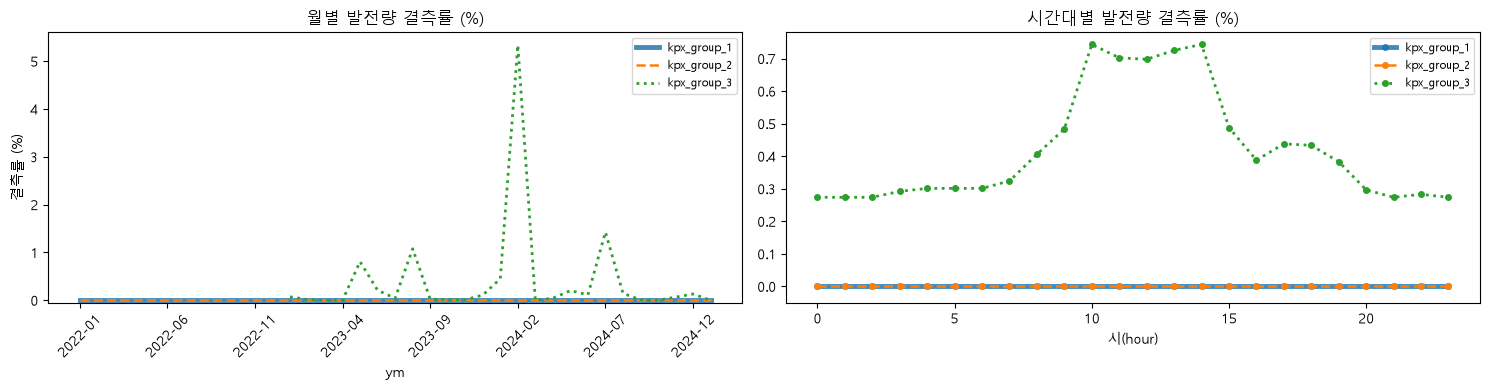

[숫자 확인] 월별 결측률(%) - 그룹별 최소~최대
group  kpx_group_1  kpx_group_2  kpx_group_3
min            0.0          0.0        0.000
max            0.0          0.0        5.335
[숫자 확인] 시간대별 결측률(%)
group    kpx_group_1  kpx_group_2  kpx_group_3
kst_dtm                                       
0                0.0          0.0        0.274
1                0.0          0.0        0.274
2                0.0          0.0        0.274
3                0.0          0.0        0.292
4                0.0          0.0        0.301
5                0.0          0.0        0.301
6                0.0          0.0        0.301
7                0.0          0.0        0.324
8                0.0          0.0        0.406
9                0.0          0.0        0.483
10               0.0          0.0        0.743
11               0.0          0.0        0.702
12               0.0          0.0        0.698
13               0.0          0.0        0.725
14               0.0          0.0        0.743
15              

In [88]:
# 그룹3(UNISON)은 2023년부터 데이터가 시작됨. 이건 결측이 아니라 '애초에 없는 기간'
# 라벨도 2022년 구간이 빈칸이라, 여기를 0으로 채우거나 앞뒤 값으로 메우면 안 된다
year_counts = scada.groupby([scada["kst_dtm"].dt.year, "group"], observed=True).size().unstack(fill_value=0)
print("연도 x 그룹별 10분 행 수 (그룹3의 2022년이 0인 게 정상)")
print(year_counts)

# 시각마다 몇 기가 살아있는지 (통신 장애를 저발전으로 오해하지 않으려면 이 정보가 필요함)
alive = scada.dropna(subset=["power_raw"]).groupby(["hour_end", "group"], observed=True).size().unstack()
print("시간별 가용 터빈 샘플 수(=터빈수x6)의 분포")
print(alive.describe().round(1))

month_na = scada.assign(ym=scada["kst_dtm"].dt.to_period("M").astype(str)).groupby(["ym", "group"], observed=True)["power_raw"].apply(lambda s: s.isna().mean() * 100).unstack()  # 월별 x 그룹 결측률
hour_na = scada.groupby([scada["kst_dtm"].dt.hour, "group"], observed=True)["power_raw"].apply(lambda s: s.isna().mean() * 100).unstack()  # 시간대별 x 그룹 결측률

# 주의: 그룹1과 그룹2는 결측률이 둘 다 정확히 0.0이라 선이 y=0에서 완전히 겹침
# 아무 설정 없이 그리면 나중에 그려지는 그룹2가 그룹1을 덮어서 그룹1이 안 보인다 -> 선 모양과 굵기를 다르게 준다
line_style = {
    "kpx_group_1": {"linestyle": "-", "linewidth": 3.5, "alpha": 0.85},  # 굵은 실선 (맨 아래에 깔림)
    "kpx_group_2": {"linestyle": "--", "linewidth": 1.8},  # 파선 -> 끊긴 틈으로 아래 실선이 비쳐 보임
    "kpx_group_3": {"linestyle": ":", "linewidth": 2.0},  # 점선
}

fig, axes = plt.subplots(1, 2, figsize=(15, 4))  # 왼쪽: 월별 결측률, 오른쪽: 시간대별 결측률
for col in month_na.columns:  # 그룹마다 따로 그려야 선 스타일을 다르게 줄 수 있음
    month_na[col].plot(ax=axes[0], label=col, **line_style[col])  # 월별 결측률 추이
axes[0].set_title("월별 발전량 결측률 (%)")  # 제목
axes[0].set_ylabel("결측률 (%)")  # y축 이름
axes[0].set_ylim(bottom=-0.05)  # 0% 선이 축 바닥에 딱 붙어 안 보이는 것을 방지
axes[0].tick_params(axis="x", rotation=45)  # x축 글자 기울이기
axes[0].legend(fontsize=8)  # 범례

for col in hour_na.columns:  # 시간대별도 같은 방식
    hour_na[col].plot(ax=axes[1], label=col, marker="o", markersize=4, **line_style[col])
axes[1].set_title("시간대별 발전량 결측률 (%)")  # 제목
axes[1].set_xlabel("시(hour)")  # x축 이름
axes[1].set_ylim(bottom=-0.05)  # 위와 같은 이유
axes[1].legend(fontsize=8)  # 범례
plt.tight_layout()  # 여백 정리
plt.show()  # 출력

# 그래프에서 겹쳐 보이는 값을 숫자로도 확인 (그림만 믿지 말 것)
print("[숫자 확인] 월별 결측률(%) - 그룹별 최소~최대")
print(month_na.agg(["min", "max"]).round(3).to_string())
print("[숫자 확인] 시간대별 결측률(%)")
print(hour_na.round(3).to_string())
print("그룹1·2는 모든 월·모든 시간대에서 결측률이 정확히 0.0 -> 그래프에서 두 선이 y=0에 완전히 겹침")
print("(VESTAS 파일에 발전량 결측이 0건이기 때문. 값이 깨끗하다는 뜻은 아니고 4절에서 볼 극단값이 숫자로 채워져 있음)")

**3절 정리**

- VESTAS는 발전량 결측이 **0건**. 대신 4절에서 볼 정격 초과 극단값이 숫자로 들어있다 -> 결측률만 보고 "깨끗하다"고 판단하면 안 됨
- UNISON은 터빈별 0.1~1.3% 정도의 결측. 05 문서 기준으로는 "10% 미만"이라 대치·삭제 둘 다 가능한 구간
- 그룹3의 2022년은 결측이 아니라 **없는 기간**. 채우지 않는다
- 결측이 특정 월·시간대에 몰려 있는지도 같이 확인 (계절 요인이나 주기적 정비가 있으면 여기서 보일 것)


## 4. 물리한계 기반 이상치 탐지
- 발전량: 제조사 홈페이지에 있는 파워 커브 데이터 사용
- 기상요소는 04. 전처리 방법론 고민 파일 참고
- LDAPS_사용하는 컬럼들: 기상청 발표 자료 참고할 지 고민중(자료 생산 방식이 서로다르다..)
- 아래 그림처럼 파워커브를 넘어 튀는 값은 따로 제거
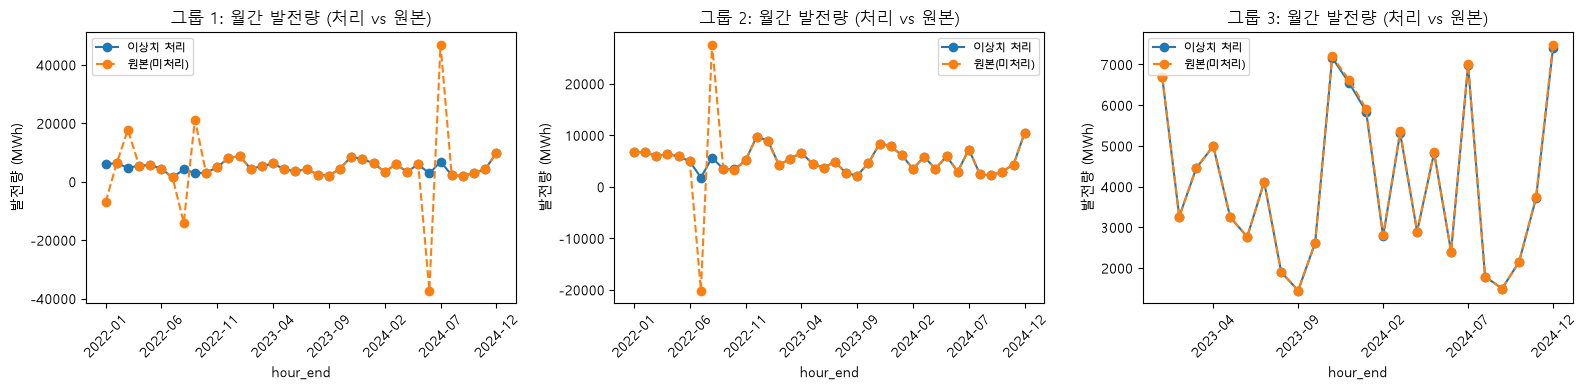

In [89]:
# 발전량·풍속의 물리한계 검사 -> 값을 바꾸지 않고 플래그(True/False) 컬럼만 만든다
cap10 = scada["cap_kwh10m"]  # 터빈별 10분 정격 발전량 (VESTAS 600, UNISON 700 kWh)

scada["is_power_outlier"] = scada["power_raw"].abs() > cap10 * POWER_CAP_RATIO  # 정격 105% 초과 = 비현실적으로 큰 값
scada["is_power_neg_large"] = scada["power_raw"] < -cap10 * NEG_POWER_RATIO  # 큰 음수 = 센서·단위 오류 의심
scada["is_power_neg_small"] = (scada["power_raw"] < 0) & (~scada["is_power_neg_large"])  # 작은 음수 = 대기전력·보조전력 가능성
scada["is_ws_out_of_range"] = (scada["ws_raw"] < 0) | (scada["ws_raw"] > WS_PHYS_MAX)  # 풍속 물리한계 밖
scada["is_cut_out"] = scada["ws_raw"] >= scada["cut_out_ms"]  # 컷아웃 이상 = 터빈을 세우는 게 정상
scada["is_low_wind_zero_power"] = (scada["ws_raw"] < CUT_IN_MS) & (scada["power_raw"] <= 0)  # 바람도 없고 발전도 0 = 정상 정지
scada["is_high_wind_zero_power"] = (
    (scada["ws_raw"] >= HIGH_WS_MS) & (scada["ws_raw"] < scada["cut_out_ms"]) & (scada["power_raw"] <= 0)
)  # 바람은 충분한데 발전이 0 = 고장·정비·출력제한 후보 (이건 절대 결측으로 바꾸면 안 되는 값)

# 센서 고착: 같은 값이 오래 반복되는 경우. 단 0이 반복되는 건 정상 정지라서 제외한다
same_as_prev = scada["power_raw"].eq(scada["power_raw"].shift()) & scada["turbine"].eq(scada["turbine"].shift())  # 직전 값과 같고, 같은 터빈인지
run_id = (~same_as_prev).cumsum()  # 값이 바뀔 때마다 번호를 올려서 '같은 값 구간'에 같은 번호 부여
run_len = scada.groupby(run_id)["power_raw"].transform("size")  # 그 구간의 길이(몇 번 반복됐는지)
scada["is_frozen_sensor"] = (run_len >= FROZEN_STEPS) & scada["power_raw"].notna() & (scada["power_raw"] != 0)  # 3시간 이상 같은 값(0 제외)

# 터빈 간 불일치: 같은 그룹·같은 시각의 다른 터빈들과 비교. 정격 초과값은 중앙값 계산에서 빼고 본다
power_for_median = scada["power_raw"].mask(scada["is_power_outlier"])  # 극단값을 뺀 발전량
group_median = power_for_median.groupby([scada["kst_dtm"], scada["group"]], observed=True).transform("median")  # 그룹·시각별 중앙값
scada["is_turbine_disagreement"] = (power_for_median - group_median).abs() > cap10 * DISAGREE_RATIO  # 중앙값과 정격 50% 이상 차이

FLAG_COLS = [
    "is_power_outlier", "is_power_neg_large", "is_power_neg_small", "is_frozen_sensor",
    "is_high_wind_zero_power", "is_low_wind_zero_power", "is_cut_out",
    "is_ws_out_of_range", "is_turbine_disagreement",
]  # 플래그 목록 (뒤에서 계속 재사용)

flag_summary = pd.DataFrame({
    "건수": scada[FLAG_COLS].sum(),
    "비율(%)": (scada[FLAG_COLS].mean() * 100).round(3),
})
print("플래그별 검출 건수 (10분 단위 기준, 전체 %d행)" % len(scada))
flag_summary

플래그별 검출 건수 (10분 단위 기준, 전체 2420148행)


,건수,비율(%)
is_power_outlier,1350,0.056
is_power_neg_large,434,0.018
is_power_neg_small,316787,13.090
is_frozen_sensor,7447,0.308
is_high_wind_zero_power,95273,3.937
is_low_wind_zero_power,391611,16.181
is_cut_out,999,0.041
is_ws_out_of_range,0,0.000
is_turbine_disagreement,45382,1.875


In [90]:
# 터빈별로 어떤 플래그가 몇 개인지도 확인
by_turbine = scada.groupby("turbine", observed=True)[FLAG_COLS].sum()
print("터빈별 플래그 건수")
by_turbine



터빈별 플래그 건수


,is_power_outlier,is_power_neg_large,is_power_neg_small,is_frozen_sensor,is_high_wind_zero_power,is_low_wind_zero_power,is_cut_out,is_ws_out_of_range,is_turbine_disagreement
turbine,,,,,,,,,
unison_wtg01,19,0,0,228,6723,26095,1,0,4516
unison_wtg02,10,0,0,412,3617,31538,33,0,2904
unison_wtg03,60,0,0,1502,3643,27317,40,0,1198
unison_wtg04,99,0,0,1265,4647,27275,96,0,1644
unison_wtg05,294,0,0,3067,4458,25170,76,0,2013
vestas_wtg01,74,37,24747,182,7603,20604,1,0,3750
vestas_wtg02,70,35,23716,22,4104,20923,40,0,2066
vestas_wtg03,88,44,21462,0,4238,19479,67,0,1026
vestas_wtg04,44,22,26701,158,8128,20272,15,0,2314


### 4-1. LDAPS에는 IQR·3σ 이상치 제거를 쓰지 않았음

ASOS·AWS는 **센서 관측자료**라 센서 고장·통신 오류를 잡는 게 목적이고,
LDAPS는 **수치예보 모델 결과**라 파일 손상·시간/격자 불일치·단위 오류·비물리적 값을 잡는 게 목적임.
목적이 다른데 같은 방법(IQR, 3σ)을 쓰면 안 됨.

그리고 더 중요한 이유: 폭풍이나 급격한 기상 변화는 통계적으로 극단값이지만 발전량 예측에서 가장 중요한 사례임.

그래서 LDAPS는 물리 일관성 검사만 하고, 값은 지우지 않고 플래그만 남긴다.

In [91]:
# LDAPS 물리 일관성 검사 (05 문서의 물리한계 개념을 모델자료에 맞게 조정)
ldaps_checks = []  # 검사 결과를 담을 리스트

n_nan = ldaps.isna().sum().sum()  # 결측 개수
n_inf = np.isinf(ldaps.select_dtypes("number").to_numpy()).sum()  # 무한대 개수
ldaps_checks.append({"검사": "NaN·Inf 없음", "결과": f"NaN {n_nan}개 / Inf {n_inf}개", "통과": "O" if n_nan == 0 and n_inf == 0 else "X"})

# 기온은 이슬점보다 같거나 높아야 한다 (이슬점이 기온보다 높으면 물리적으로 불가능)
ldaps["is_temp_below_dew"] = ldaps["t2m"] < ldaps["dpt2m"]  # 플래그로 남기기
ldaps_checks.append({"검사": "기온 >= 이슬점", "결과": f"위반 {int(ldaps['is_temp_below_dew'].sum())}건", "통과": "O" if not ldaps["is_temp_below_dew"].any() else "X"})

# 상대습도는 0~100%가 정상 범위. 모델 산출물이라 100을 살짝 넘는 값이 실제로 있었음
ldaps["is_rh_over_100"] = ldaps["rh2m"] > 100  # 플래그로 남기기 (지우지 않음)
ldaps_checks.append({"검사": "상대습도 0~100%", "결과": f"100% 초과 {int(ldaps['is_rh_over_100'].sum())}건, 최대 {ldaps['rh2m'].max():.1f}%", "통과": "X"})

# 기압·비습이 단위에 맞는 범위인지 (2-1절 단위 확인과 짝을 이루는 검사)
ldaps_checks.append({"검사": "기압 5~110 kPa", "결과": f"{ldaps['sp'].min():.0f} ~ {ldaps['sp'].max():.0f} Pa", "통과": "O"})
ldaps_checks.append({"검사": "비습 0~0.05 kg/kg", "결과": f"{ldaps['q2m'].min():.5f} ~ {ldaps['q2m'].max():.5f}", "통과": "O"})
ldaps_checks.append({"검사": "육지/해양 마스크", "결과": f"lsm 값 종류 = {sorted(ldaps['lsm'].unique())} (전부 육지)", "통과": "O"})

ldaps_qc_report = pd.DataFrame(ldaps_checks)  # LDAPS 품질검사 표
print("LDAPS 품질검사 (통과 X여도 값을 지우지 않고 플래그만 남긴다)")
ldaps_qc_report

LDAPS 품질검사 (통과 X여도 값을 지우지 않고 플래그만 남긴다)


,검사,결과,통과
0,NaN·Inf 없음,NaN 0개 / Inf 0개,O
1,기온 >= 이슬점,위반 6398건,X
2,상대습도 0~100%,"100% 초과 16649건, 최대 110.4%",X
3,기압 5~110 kPa,87463 ~ 93083 Pa,O
4,비습 0~0.05 kg/kg,0.00024 ~ 0.02125,O
5,육지/해양 마스크,lsm 값 종류 = [np.float64(1.0)] (전부 육지),O


**4절 정리**

- SCADA 발전량 정격 105% 초과는 VESTAS에서만 나옴 -> 5절에서 NaN 처리
- `is_high_wind_zero_power`(바람은 충분한데 발전 0)는 고장·정비·출력제한 후보. **이건 결측으로 바꾸지 않는다**
- `is_low_wind_zero_power`(바람도 없고 발전 0)는 정상 정지. 이것도 그대로 둔다
- 작은 음수는 대기전력일 수 있어서 지우지 않고 플래그만
- LDAPS는 상대습도 100% 초과가 있지만 모델 산출물 특성이므로 플래그만 남기고 값은 유지


## 5. 이상치를 NaN 으로 변환
- 이상치 어떻게 보간할지 생각해야 됨
- 보간법은 보내준 자료 참고.

In [92]:
# 원본 컬럼은 그대로 두고, 정제값을 별도 컬럼으로 만든다
DROP_FLAGS = ["is_power_outlier", "is_power_neg_large", "is_frozen_sensor"]  # 이 세 가지만 값을 못 믿겠다고 판단해 NaN 처리
KEEP_FLAGS = ["is_power_neg_small", "is_high_wind_zero_power", "is_low_wind_zero_power", "is_cut_out"]  # 이건 실제 운영 상태라서 값을 유지

scada["power_clean"] = scada["power_raw"].mask(scada[DROP_FLAGS].any(axis=1))  # 못 믿을 값만 NaN으로
scada["ws_clean"] = scada["ws_raw"].mask(scada["is_ws_out_of_range"])  # 물리한계 밖 풍속만 NaN으로
scada["wd_clean"] = scada["wd_raw"] % 360  # UNISON은 -180~180 표기라서 0~360으로 통일 (VESTAS는 원래 0~360이라 변화 없음)

# 어떤 플래그가 걸렸는지를 한 컬럼에 담아두기 (비트 코드). 나중에 특정 상태만 골라볼 때 편함
QC_BITS = {name: 1 << i for i, name in enumerate(FLAG_COLS)}  # 플래그마다 2의 거듭제곱 값을 하나씩 배정
qc_code = np.zeros(len(scada), dtype=np.int32)  # 0으로 시작
for name, bit in QC_BITS.items():  # 플래그마다
    qc_code += scada[name].to_numpy() * bit  # True인 행에만 그 비트를 더하기
scada["power_qc_flag"] = qc_code  # 정수 하나로 상태 기록

# 시간당 부분 결측 여부 (10분값이 1~5개만 남은 시간)
n_valid_hour = scada.groupby(["turbine", "hour_end"], observed=True)["power_clean"].transform("count")  # 그 시간의 유효 샘플 수
scada["n_valid_in_hour"] = n_valid_hour  # 나중에 집계에서 재사용
scada["is_partial_missing"] = (n_valid_hour > 0) & (n_valid_hour < MIN_SAMPLES_PER_HOUR)  # 일부만 있는 경우
scada["is_full_missing_hour"] = n_valid_hour == 0  # 그 시간이 통째로 비어있는 경우

print("정제 전후 비교")
print(f"  power_raw  결측: {scada['power_raw'].isna().sum():,}건")
print(f"  power_clean 결측: {scada['power_clean'].isna().sum():,}건 (플래그로 NaN 처리한 만큼 늘어남)")
print(f"  발전량 0인 행: {(scada['power_clean'] == 0).sum():,}건 <- 이건 NaN으로 바꾸지 않고 그대로 둔다")
print(f"  부분 결측 시간에 속한 행: {int(scada['is_partial_missing'].sum()):,}건")
print(f"  통째로 빈 시간에 속한 행: {int(scada['is_full_missing_hour'].sum()):,}건")
print("\nQC 비트 배정:", QC_BITS)

정제 전후 비교
  power_raw  결측: 2,214건
  power_clean 결측: 11,011건 (플래그로 NaN 처리한 만큼 늘어남)
  발전량 0인 행: 322,148건 <- 이건 NaN으로 바꾸지 않고 그대로 둔다
  부분 결측 시간에 속한 행: 8,916건
  통째로 빈 시간에 속한 행: 8,166건

QC 비트 배정: {'is_power_outlier': 1, 'is_power_neg_large': 2, 'is_power_neg_small': 4, 'is_frozen_sensor': 8, 'is_high_wind_zero_power': 16, 'is_low_wind_zero_power': 32, 'is_cut_out': 64, 'is_ws_out_of_range': 128, 'is_turbine_disagreement': 256}


**5절 정리**

- `power_raw`(원본) / `power_clean`(정제) / `power_qc_flag`(비트 코드) 세 컬럼 구조로 남겼음. 원본을 지우지 않았으니 언제든 되돌려 확인 가능
- NaN으로 바꾼 건 **정격 초과 · 큰 음수 · 센서 고착** 세 가지뿐
- 발전량 0, 작은 음수, 고풍속 무발전, 컷아웃은 값을 그대로 유지하고 플래그만 남김
- UNISON 풍향의 -180~180 표기를 0~360으로 통일 (`% 360`)


## 6. 결측 패턴·연속 길이 분석
- 의심. 결측값에도 패턴이 있다면 계절 요인 영향/주기적인 정비소요 등등으로 반복되지 않을까?


In [93]:
# 결측이 얼마나 길게 이어지는지(연속 결측 길이)를 먼저 계산. 짧은 구멍은 메울 수 있지만 긴 구멍은 손대면 안 됨
na_mask = scada["power_clean"].isna()  # 결측 여부
same_run = na_mask.eq(na_mask.shift()) & scada["turbine"].eq(scada["turbine"].shift())  # 직전 행과 같은 상태이고 같은 터빈인지
na_run_id = (~same_run).cumsum()  # 상태가 바뀔 때마다 번호를 올려 '같은 상태 구간'에 같은 번호 부여
na_run_len = scada.groupby(na_run_id)["power_clean"].transform("size")  # 그 구간의 길이
scada["na_run_len"] = na_run_len.where(na_mask, 0).astype("int32")  # 결측 구간에만 길이를 적고, 값이 있는 행은 0

# 구간(run) 단위로 한 줄씩 뽑아 길이 분포를 본다
runs = pd.DataFrame({"turbine": scada["turbine"], "run_id": na_run_id, "is_na": na_mask, "len": na_run_len})
gap_runs = runs[runs["is_na"]].drop_duplicates("run_id")  # 결측 구간만, 구간당 한 줄
print(f"결측 구간 개수: {len(gap_runs):,}개")
print("\n연속 결측 길이 분포 (10분 단위. 1=10분, 6=1시간, 144=1일)")
print(gap_runs["len"].describe().round(1))
print("\n길이별 구간 개수 (상위 10개)")
print(gap_runs["len"].value_counts().sort_index().head(10))
print(f"\n20분 이하 짧은 구멍: {int((gap_runs['len'] <= MAX_INTERP_STEPS).sum()):,}개 구간 -> 7절에서 보간")
print(f"그보다 긴 구멍: {int((gap_runs['len'] > MAX_INTERP_STEPS).sum()):,}개 구간 -> 보간하지 않고 플래그 유지")

결측 구간 개수: 1,295개

연속 결측 길이 분포 (10분 단위. 1=10분, 6=1시간, 144=1일)
count    1295.0
mean        8.5
std        22.1
min         1.0
25%         1.0
50%         1.0
75%         3.0
max       430.0
Name: len, dtype: float64

길이별 구간 개수 (상위 10개)
len
1     759
2     203
3      11
4       7
5       2
6       6
7       2
8       5
9       3
11      1
Name: count, dtype: int64

20분 이하 짧은 구멍: 962개 구간 -> 7절에서 보간
그보다 긴 구멍: 333개 구간 -> 보간하지 않고 플래그 유지


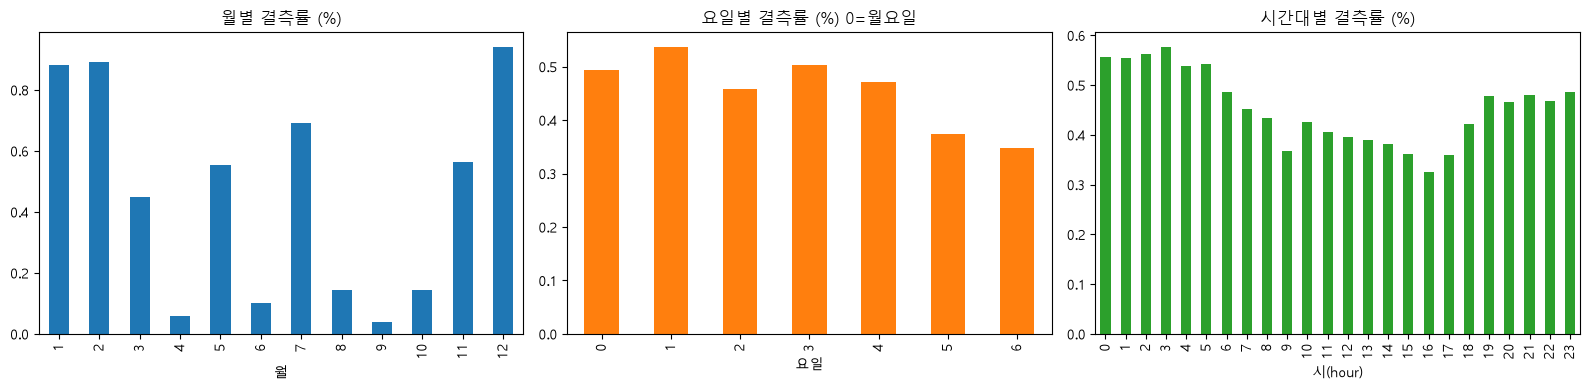

주간(9~17시) 결측률 0.38%  vs  그 외 시간 0.50%


In [94]:
# 의심 검증: 결측에도 계절 요인이나 주기적 정비 패턴이 있을까?
fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 월별 / 요일별 / 시간대별

by_month = scada.groupby(scada["kst_dtm"].dt.month, observed=True)["power_clean"].apply(lambda s: s.isna().mean() * 100)
by_month.plot(kind="bar", ax=axes[0], color="tab:blue")  # 월별 결측률
axes[0].set_title("월별 결측률 (%)")  # 제목
axes[0].set_xlabel("월")  # x축 이름

by_dow = scada.groupby(scada["kst_dtm"].dt.dayofweek, observed=True)["power_clean"].apply(lambda s: s.isna().mean() * 100)
by_dow.plot(kind="bar", ax=axes[1], color="tab:orange")  # 요일별 결측률 (0=월요일)
axes[1].set_title("요일별 결측률 (%) 0=월요일")  # 제목
axes[1].set_xlabel("요일")  # x축 이름

by_hour = scada.groupby(scada["kst_dtm"].dt.hour, observed=True)["power_clean"].apply(lambda s: s.isna().mean() * 100)
by_hour.plot(kind="bar", ax=axes[2], color="tab:green")  # 시간대별 결측률
axes[2].set_title("시간대별 결측률 (%)")  # 제목
axes[2].set_xlabel("시(hour)")  # x축 이름

plt.tight_layout()  # 여백 정리
plt.show()  # 출력

# 정비는 보통 낮 시간에 하니까, 낮에 결측이 몰려 있으면 정비 흔적일 가능성이 있다
day_na = scada.loc[scada["kst_dtm"].dt.hour.between(9, 17), "power_clean"].isna().mean() * 100  # 주간(9~17시)
night_na = scada.loc[~scada["kst_dtm"].dt.hour.between(9, 17), "power_clean"].isna().mean() * 100  # 그 외 시간
print(f"주간(9~17시) 결측률 {day_na:.2f}%  vs  그 외 시간 {night_na:.2f}%")

**6절 정리**

- 결측 구간 길이 분포를 보면 짧은 구멍(10~20분)과 긴 구멍(수시간~수일)이 섞여 있음
- 짧은 구멍은 통신 순간 끊김으로 보이고, 긴 구멍은 정비·고장 가능성 -> 처리 방법을 다르게 가야 함
- 월·요일·시간대별 결측률을 비교해서 계절·정비 패턴이 있는지 확인 (주간 결측률이 더 높으면 정비 흔적 의심)


## 7. 단기 결측 보간·장기 결측 플래그 처리
- 발전량, 풍속을 선형보간


In [95]:
def fill_short_gaps(df, col, key="turbine", max_steps=MAX_INTERP_STEPS):
    # 연속 결측이 max_steps 이하인 '짧은 구멍'만 선형보간하고 긴 구멍은 그대로 두는 함수 (재사용)
    na = df[col].isna()  # 결측 여부
    same = na.eq(na.shift()) & df[key].eq(df[key].shift())  # 직전 행과 같은 상태이고 같은 터빈인지
    run_len = df.groupby((~same).cumsum())[col].transform("size")  # 연속 구간 길이
    short = na & (run_len <= max_steps)  # 짧은 구멍만 True
    interp = df.groupby(key, observed=True)[col].transform(lambda s: s.interpolate(method="linear", limit_area="inside"))  # 터빈별 선형보간 (양쪽에 값이 있을 때만)
    filled = df[col].where(~short, interp)  # 짧은 구멍 자리에만 보간값을 넣기
    return filled, (short & filled.notna())  # (채운 결과, 실제로 채운 자리 표시)


scada["power_filled"], scada["is_power_interpolated"] = fill_short_gaps(scada, "power_clean")  # 발전량 짧은 구멍 메우기
scada["ws_filled"], scada["is_ws_interpolated"] = fill_short_gaps(scada, "ws_clean")  # 풍속 짧은 구멍 메우기

print("보간 결과")
print(f"  power: 결측 {scada['power_clean'].isna().sum():,}건 -> {scada['power_filled'].isna().sum():,}건 (보간 {int(scada['is_power_interpolated'].sum()):,}건)")
print(f"  ws   : 결측 {scada['ws_clean'].isna().sum():,}건 -> {scada['ws_filled'].isna().sum():,}건 (보간 {int(scada['is_ws_interpolated'].sum()):,}건)")
print("\n남은 결측은 20분보다 긴 구멍이라 일부러 채우지 않았음")
print("긴 구멍을 억지로 채우면 통신 장애나 정비 정지를 '실제 저발전'으로 학습하게 됨 (06 문서 2.2)")

# 보간한 자리는 표시로 남겨서 재현·분석이 가능하게 한다
print(f"\n보간 표시가 남은 행: power {int(scada['is_power_interpolated'].sum()):,}건 / ws {int(scada['is_ws_interpolated'].sum()):,}건")

보간 결과
  power: 결측 11,011건 -> 9,846건 (보간 1,165건)
  ws   : 결측 5,096건 -> 4,849건 (보간 247건)

남은 결측은 20분보다 긴 구멍이라 일부러 채우지 않았음
긴 구멍을 억지로 채우면 통신 장애나 정비 정지를 '실제 저발전'으로 학습하게 됨 (06 문서 2.2)

보간 표시가 남은 행: power 1,165건 / ws 247건


**7절 정리**

- 20분(10분값 2칸) 이하 짧은 구멍만 선형보간, 그보다 긴 구멍은 **일부러 비워둠**
- 보간한 자리는 `is_power_interpolated` / `is_ws_interpolated`로 표시 -> 나중에 "보간값을 빼고 학습" 실험도 가능
- 풍향은 각도라서 선형보간하면 0도와 359도 사이에서 엉뚱한 값이 나옴. 그래서 여기서 안 건드리고, 8절에서 U·V 성분으로 바꾼 다음에 다룬다


## 8. SCADA·LDAPS 파생변수 생성
- 발전량 산출 공식에 들어가는 풍향, 풍속, 공기밀도, 수풍면적 파생변수 추가.
- 04. 전처리 방법론 고민.pdf 참고

### 8-1. LDAPS 격자 단위 파생변수

중요한 순서 문제: 공기밀도나 풍력에너지 밀도처럼 **비선형** 계산은 격자별로 먼저 계산하고 나중에 평균해야 함.
평균 기온·평균 기압으로 밀도를 한 번 계산하면 값이 미묘하게 틀림

풍향은 04 문서에서 정리한 대로 `atan2(-u, -v)`를 쓴다.
`atan(v/u)`를 쓰면 부호를 하나만 보기 때문에 동북풍과 서남풍을 구분하지 못하고, u=0에서 0으로 나누는 문제도 생김

In [96]:
# --- 풍속·풍향  ---
ldaps["ws10"] = np.sqrt(ldaps["u10"] ** 2 + ldaps["v10"] ** 2)  # 피타고라스 정리로 풍속 크기
ldaps["wd10"] = (np.degrees(np.arctan2(-ldaps["u10"], -ldaps["v10"])) + 360) % 360  # 기상학적 풍향(바람이 불어오는 방향)
ldaps["wd10_sin"] = np.sin(np.deg2rad(ldaps["wd10"]))  # 360도와 0도가 같은 방향이라는 걸 모델에 알려주려면 sin·cos으로 넣어야 함
ldaps["wd10_cos"] = np.cos(np.deg2rad(ldaps["wd10"]))  # 위와 같은 이유

# --- 공기밀도  ---
ldaps["e_pa"] = (ldaps["q2m"] * ldaps["sp"]) / (EPSILON + ONE_MINUS_EPS * ldaps["q2m"])  # 비습 -> 수증기압(Pa)
ldaps["air_density"] = (ldaps["sp"] - 0.378 * ldaps["e_pa"]) / (R_D * ldaps["t2m"])  # 습윤공기 밀도(kg/m³)

# --- 풍력에너지 밀도 (단위면적당 바람이 가진 힘) ---
ldaps["wind_power_density"] = 0.5 * ldaps["air_density"] * ldaps["ws10"] ** 3  # W/m². 발전량이 여기 정비례한다고 강제하진 않고 입력변수로만 씀

# --- 50m 바람의 변동폭 (06 문서 2.6) ---
# 주의: 50MUmax와 50MVmax를 직접 합쳐서 '최대 풍속 벡터'를 만들면 안 됨. 두 최댓값이 같은 시점에 발생했다는 보장이 없음
ldaps["u50_range"] = ldaps["u50_max"] - ldaps["u50_min"]  # U 성분 변동폭 -> 난류·돌풍 대리변수
ldaps["v50_range"] = ldaps["v50_max"] - ldaps["v50_min"]  # V 성분 변동폭
ldaps["blws"] = np.sqrt(ldaps["blws_x"] ** 2 + ldaps["blws_y"] ** 2)  # 경계층 바람 크기
ldaps["t_dew_diff"] = ldaps["t2m"] - ldaps["dpt2m"]  # 기온-이슬점 차 (건조한지 습한지)

print("공기밀도 확인 (표준 대기 1.225 kg/m³ 근처여야 정상. 태백 산지 900m 고도라 조금 낮게 나오는 게 맞다)")
print(ldaps[["sp", "t2m", "q2m", "e_pa", "air_density", "ws10", "wind_power_density"]].describe().T[["min", "mean", "max"]].round(4))
in_range = ldaps["air_density"].between(0.9, 1.4).mean() * 100  # 현실적인 범위에 몇 %가 들어오는지
print(f"\n공기밀도가 0.9~1.4 kg/m³ 안에 있는 비율: {in_range:.2f}%")

공기밀도 확인 (표준 대기 1.225 kg/m³ 근처여야 정상. 태백 산지 900m 고도라 조금 낮게 나오는 게 맞다)
                           min        mean         max
sp                  87462.8100  90673.4919  93083.1300
t2m                   249.6983    281.1693    302.9151
q2m                     0.0002      0.0070      0.0212
e_pa                   35.0660   1015.4268   3031.5979
air_density             1.0224      1.1205      1.2672
ws10                    0.0056      4.8362     18.4123
wind_power_density      0.0000    128.6540   3601.8207

공기밀도가 0.9~1.4 kg/m³ 안에 있는 비율: 100.00%


### 8-1-1. 풍향 변환이 진짜 맞는지 검증

04 문서 마지막에 정리해둔 검증표를 그대로 코드로 확인함.
`u, v`를 넣었을 때 풍향이 남풍 180도 / 북풍 0도 / 서풍 270도 / 동풍 90도로 나와야 맞다.

In [97]:
# 04 문서의 검증표를 그대로 재현 (부호 실수는 여기서 안 잡으면 끝까지 못 잡는다)
check_uv = pd.DataFrame({
    "u": [0.0, 0.0, 1.0, -1.0],  # 동서 성분
    "v": [1.0, -1.0, 0.0, 0.0],  # 남북 성분
    "기대 풍향": [180.0, 0.0, 270.0, 90.0],  # 04 문서에 적어둔 정답
    "의미": ["남풍(남쪽에서 옴)", "북풍(북쪽에서 옴)", "서풍(서쪽에서 옴)", "동풍(동쪽에서 옴)"],
})
check_uv["계산 풍향"] = (np.degrees(np.arctan2(-check_uv["u"], -check_uv["v"])) + 360) % 360  # 본문과 똑같은 식
check_uv["일치"] = np.isclose(check_uv["계산 풍향"], check_uv["기대 풍향"])  # 기대값과 같은지
print("풍향 변환 검증 (일치가 전부 True여야 함)")
check_uv

풍향 변환 검증 (일치가 전부 True여야 함)


,u,v,기대 풍향,의미,계산 풍향,일치
0,0.0,1.0,180.0,남풍(남쪽에서 옴),180.0,True
1,0.0,-1.0,0.0,북풍(북쪽에서 옴),0.0,True
2,1.0,0.0,270.0,서풍(서쪽에서 옴),270.0,True
3,-1.0,0.0,90.0,동풍(동쪽에서 옴),90.0,True


### 8-1-2. 시간·공간 급변값은 지우지 않고 플래그만

- 폭풍처럼 급격한 변화 고려해야 함
- 통계적으로는 이상치지만 **발전량 예측에서 가장 중요한 사례**라 지우면 손해임.

In [98]:
ldaps = ldaps.sort_values(["grid_id", "forecast_kst_dtm"], ignore_index=True)  # 격자별 시간순 정렬 (변화량 계산 전에 필수)
ldaps["ws10_diff_1h"] = ldaps.groupby("grid_id")["ws10"].diff()  # 같은 격자에서 1시간 사이 풍속 변화량
ldaps["is_ws_time_jump"] = ldaps["ws10_diff_1h"].abs() > 15  # 1시간에 15 m/s 넘게 변하면 급변으로 표시

ws_by_time = ldaps.groupby("forecast_kst_dtm")["ws10"]  # 같은 시각의 16격자
ldaps["ws10_spatial_range"] = ws_by_time.transform("max") - ws_by_time.transform("min")  # 격자 간 풍속 최대-최소 (공간 불확실성)
ldaps["is_ws_space_jump"] = ldaps["ws10_spatial_range"] > 10  # 같은 시각인데 격자 간 10 m/s 이상 벌어지면 표시

print(f"시간 급변 플래그: {int(ldaps['is_ws_time_jump'].sum()):,}건 ({ldaps['is_ws_time_jump'].mean() * 100:.3f}%)")
print(f"공간 급변 플래그: {int(ldaps['is_ws_space_jump'].sum()):,}건 ({ldaps['is_ws_space_jump'].mean() * 100:.3f}%)")
print("\n격자 간 풍속 편차(ws10_spatial_range) 분포 - 16격자를 통째로 평균하면 이 정보가 사라진다")
print(ldaps.groupby("forecast_kst_dtm")["ws10_spatial_range"].first().describe().round(2))

시간 급변 플래그: 0건 (0.000%)
공간 급변 플래그: 16건 (0.004%)

격자 간 풍속 편차(ws10_spatial_range) 분포 - 16격자를 통째로 평균하면 이 정보가 사라진다
count    26304.00
mean         2.46
std          1.31
min          0.15
25%          1.47
50%          2.21
75%          3.18
max         10.62
Name: ws10_spatial_range, dtype: float64


### 8-2. SCADA 풍향도 각도 대신 U·V로 바꿈

풍향을 각도 상태로 평균하면 0도와 359도의 평균이 180도가 되는 사고가 남.
그래서 터빈별로 먼저 U·V 성분으로 바꿔두고, 평균은 성분 단위로 한다.

기상학적 풍향(바람이 불어오는 방향)에서 성분으로 갈 때는 부호를 뒤집어야 함
- `u = -ws × sin(풍향)`
- `v = -ws × cos(풍향)`

In [99]:
rad = np.deg2rad(scada["wd_clean"])  # 풍향(도)을 라디안으로
scada["u_scada"] = (-scada["ws_filled"] * np.sin(rad)).astype("float32")  # 동서(U) 성분. 앞에 마이너스가 붇는 이유는 04 문서 참고
scada["v_scada"] = (-scada["ws_filled"] * np.cos(rad)).astype("float32")  # 남북(V) 성분

# U·V로 바꾼 다음에 짧은 구멍을 메운다 (각도를 직접 보간하면 0도/359도 경계에서 엉뚱한 값이 나옴)
scada["u_scada"], scada["is_u_interpolated"] = fill_short_gaps(scada, "u_scada")  # U 성분 짧은 구멍 보간
scada["v_scada"], _ = fill_short_gaps(scada, "v_scada")  # V 성분도 같이

scada["dir_valid"] = scada["ws_filled"] >= LOW_WS_MASK  # 풍속이 거의 0일 때 풍향은 의미가 약해서, 방향 통계에서는 빼둔다

print("SCADA U·V 성분 변환 결과")
print(scada[["ws_filled", "wd_clean", "u_scada", "v_scada"]].describe().T[["min", "mean", "max"]].round(3))
print(f"\n방향 통계에서 제외할 저풍속 행(풍속 < {LOW_WS_MASK} m/s): {int((~scada['dir_valid']).sum()):,}건")

# 되돌려서 원래 풍향이 복원되는지 확인 (변환 실수 검증)
back = (np.degrees(np.arctan2(-scada["u_scada"], -scada["v_scada"])) + 360) % 360  # U·V -> 풍향 복원
ok = scada["dir_valid"] & scada["wd_clean"].notna() & scada["u_scada"].notna()  # 비교 가능한 행만
diff = ((back - scada["wd_clean"] + 180) % 360 - 180).abs()  # 각도 차이를 -180~180으로 감아서 절댓값
print(f"복원한 풍향과 원래 풍향의 평균 차이: {diff[ok].mean():.6f}도 (0에 가까워야 정상)")

SCADA U·V 성분 변환 결과
              min     mean      max
ws_filled   0.000    6.743   32.050
wd_clean    0.000  206.341  359.891
u_scada   -20.297    3.959   30.332
v_scada   -18.108    0.482   26.024

방향 통계에서 제외할 저풍속 행(풍속 < 1.0 m/s): 50,215건
복원한 풍향과 원래 풍향의 평균 차이: 0.000006도 (0에 가까워야 정상)


### 8-3. 수풍면적과 이론 출력

04 문서에서 정리한 발전량 공식은 이것

$$P = \frac{1}{2} \rho A V^3 C_p$$

여기서 A(수풍면적)는 터빈 모델마다 고정값임. 스펙 시트 값을 쓴다
- V126: 12,469 m² (로터 126m)
- U136: 14,470 m² (로터 136m)

참고: 04 문서에서는 U136을 π×68² ≈ 14,527 m²로 추정했는데, 실제 스펙 시트 값은 14,470 m²라 그쪽을 씀

`Cp`(터빈 효율)는 우리가 모르는 값이라, 여기서는 표준 밀도로 이론 출력만 구해두고
실제 발전량과 비교해 Cp가 대략 얼마쯤 나오는지 확인한다.

In [100]:
# 표준 밀도(1.225)로 계산한 이론 출력. 실제 밀도는 LDAPS에서 오므로 10절 결합 후에 다시 계산할 수 있음
scada["p_theory_std_kw"] = (0.5 * RHO_STD * scada["swept_area_m2"] * scada["ws_filled"] ** 3 / 1000).astype("float32")  # W -> kW
scada["power_kw"] = (scada["power_filled"] * 6).astype("float32")  # 10분 에너지(kWh)를 순간 출력(kW)으로 환산 (1시간의 1/6이므로 ×6)

# Cp가 물리적으로 가능한 범위(베츠 한계 0.593 이하)에 들어오는지, 컷인~정격 사이 구간에서만 확인
band = scada["ws_filled"].between(CUT_IN_MS, 10) & (scada["power_kw"] > 0) & scada["p_theory_std_kw"].notna()  # 정격 포화 전 구간
cp_est = (scada.loc[band, "power_kw"] / scada.loc[band, "p_theory_std_kw"])  # 실제 출력 / 이론 출력
print("모델별 수풍면적:", SWEPT_AREA_M2)
print("\n컷인~10m/s 구간에서 추정한 Cp")
print(cp_est.groupby(scada.loc[band, "model"], observed=True).describe()[["count", "mean", "50%", "max"]].round(3))

# 의심: 중앙값(V126 0.35, U136 0.50)은 그럴듯한데 최댓값이 베츠 한계(0.593)를 훌쩍 넘는다. 왜지
over_betz = (cp_est > 0.593).groupby(scada.loc[band, "model"], observed=True).mean() * 100  # 모델별로 한계를 넘는 비율
print(f"\n베츠 한계(0.593) 초과 비율: {over_betz.round(1).to_dict()}")
print("계산이 틀린 게 아니라, SCADA 풍속계가 나셀(로터 뒤쪽)에 달려 있어서 후류 영향으로 풍속을 낮게 읽는 탓으로 보인다.")
print("게다가 10분 평균 풍속을 세제곱하면 원래 값보다 작아지는 방향으로 편향됨(젠센 부등식).")
print("-> 이래서 발전량÷풍속³을 터빈 효율로 바로 해석하면 안 됨 (06 문서 2.11). 파워커브 잔차로 봐야 한다.")

모델별 수풍면적: {'V126': 12469.0, 'U136': 14470.0}

컷인~10m/s 구간에서 추정한 Cp
           count   mean    50%    max
model                                
U136    232266.0  0.576  0.495  7.816
V126   1070134.0  0.317  0.349  1.171

베츠 한계(0.593) 초과 비율: {'U136': 33.9, 'V126': 0.1}
계산이 틀린 게 아니라, SCADA 풍속계가 나셀(로터 뒤쪽)에 달려 있어서 후류 영향으로 풍속을 낮게 읽는 탓으로 보인다.
게다가 10분 평균 풍속을 세제곱하면 원래 값보다 작아지는 방향으로 편향됨(젠센 부등식).
-> 이래서 발전량÷풍속³을 터빈 효율로 바로 해석하면 안 됨 (06 문서 2.11). 파워커브 잔차로 봐야 한다.


**8절 정리**

- LDAPS 파생변수는 **격자별로 먼저** 계산했음 (공기밀도·풍력에너지 밀도가 비선형이라 평균 순서가 중요)
- 풍향 변환은 04 문서의 검증표(남풍 180 / 북풍 0 / 서풍 270 / 동풍 90)로 확인 완료
- SCADA 풍향은 U·V로 바꾼 뒤 보간·평균. 되돌려서 원래 각도가 복원되는 것까지 확인
- 50m 바람은 max·min을 직접 합치지 않고 **변동폭**으로만 사용
- 시간 급변(1시간 15m/s 초과)은 0건, 공간 급변(격자 간 10m/s 초과)은 16건. 삭제하지 않고 플래그만 남김
- Cp 추정 결과 중앙값은 그럴듯한데 **베츠 한계를 넘는 값이 섞여 있음** -> 나셀 풍속계 후류 영향으로 보임.
  발전량÷풍속³을 효율로 쓰면 안 되는 이유를 숫자로 확인한 셈


## 9. 10분 SCADA를 시간 단위로 집계
- 단순 총합 하면 될 것 같다.
- (수정) 처음엔 "단순 총합 하면 될 것 같다"고 적어뒀는데, 06 문서 2.2를 보고 생각을 바꿈.

총합 자체는 맞다. 문제는 **결측이 있을 때**임

```python
# 이렇게 하면 안 된다...
df.groupby("hour_end")[power_cols].sum(min_count=1).sum(axis=1)
```

- 어떤 터빈에 10분 자료가 한두 개만 있어도 그걸 정상적인 1시간 발전량으로 써버림
- 모든 값이 결측인 터빈은 첫 합계에서 NaN이 되지만, 두 번째 `sum(axis=1)`에서 그 NaN이 **무시**됨
  -> 터빈이 전부 죽어 있어도 그룹 발전량 계산

- 즉 센서 고장이나 센서 장애를 실제 저발전으로 학습하게 될 가능성을 배제할 수 없음. 그래서 `min_count`를 두 단계 모두에 명시한다.

In [101]:
# --- 1단계: 터빈 × 시간 집계 ---
g = scada.groupby(["turbine", "hour_end"], observed=True)  # 터빈별·시간별 묶음
agg_turbine = g.agg(
    n_valid=("power_filled", "count"),  # 그 시간에 살아있는 10분값 개수 (0~6)
    power_sum_all=("power_filled", "sum"),  # 일단 합계 (min_count은 아래에서 직접 적용)
    ws_mean=("ws_filled", "mean"),  # 풍속 평균
    ws_std=("ws_filled", "std"),  # 풍속 표준편차 (10분 사이 변동)
    ws_max=("ws_filled", "max"),  # 풍속 최댓값
    u_mean=("u_scada", "mean"),  # U 성분 평균
    v_mean=("v_scada", "mean"),  # V 성분 평균
    is_high_wind_zero=("is_high_wind_zero_power", "any"),  # 이 시간에 고풍속 무발전이 있었나
    is_cut_out_hour=("is_cut_out", "any"),  # 이 시간에 컷아웃이 있었나
    is_outlier_hour=("is_power_outlier", "any"),  # 이 시간에 정격 초과가 있었나
    is_interp_hour=("is_power_interpolated", "any"),  # 이 시간에 보간한 값이 섞였나
).reset_index()

ws_q = g["ws_filled"].quantile([0.25, 0.75]).unstack()  # 풍속 25%·75% 분위수 (groupby.quantile은 빠름)
ws_q.columns = ["ws_q25", "ws_q75"]  # 컬럼 이름 정리
agg_turbine = agg_turbine.merge(ws_q.reset_index(), on=["turbine", "hour_end"], how="left")  # 분위수 붙이기

# 06 문서 권장대로 min_count을 명시: 10분값 6개가 다 있을 때만 그 시간 발전량으로 인정
agg_turbine["power_sum_strict"] = agg_turbine["power_sum_all"].where(agg_turbine["n_valid"] >= MIN_SAMPLES_PER_HOUR)
# 5/6만 있어도 쓰는 버전도 같이 만든다. 단순히 5개를 더하면 과소평가되니 6/n으로 보정
agg_turbine["power_sum_relaxed"] = (
    agg_turbine["power_sum_all"] * MIN_SAMPLES_PER_HOUR / agg_turbine["n_valid"]
).where(agg_turbine["n_valid"] >= MIN_SAMPLES_RELAXED)

agg_turbine["group"] = agg_turbine["turbine"].map(turbine_group)  # 그룹 붙이기
agg_turbine["cap_kwh10m"] = agg_turbine["turbine"].map(turbine_cap_kwh10m)  # 10분 정격 붙이기

print(f"터빈 × 시간 집계: {len(agg_turbine):,}행 (터빈 17기 × 시간)")
print(f"  6개 다 있는 시간: {(agg_turbine['n_valid'] == 6).mean() * 100:.2f}%")
print(f"  1~5개만 있는 시간: {agg_turbine['n_valid'].between(1, 5).mean() * 100:.2f}%")
print(f"  통째로 빈 시간: {(agg_turbine['n_valid'] == 0).mean() * 100:.2f}%")
agg_turbine.head(3)

터빈 × 시간 집계: 403,368행 (터빈 17기 × 시간)
  6개 다 있는 시간: 99.52%
  1~5개만 있는 시간: 0.14%
  통째로 빈 시간: 0.34%


,turbine,hour_end,n_valid,power_sum_all,ws_mean,ws_std,ws_max,u_mean,v_mean,is_high_wind_zero,is_cut_out_hour,is_outlier_hour,is_interp_hour,ws_q25,ws_q75,power_sum_strict,power_sum_relaxed,group,cap_kwh10m
0,unison_wtg01,2023-01-01 01:00:00,6,3429.0,13.936666,0.670870,14.62,13.559021,-3.207972,True,False,False,False,13.6400,14.4925,3429.0,3429.0,kpx_group_3,700.0
1,unison_wtg01,2023-01-01 02:00:00,6,0.0,12.275001,0.816302,13.44,11.724780,-3.611785,True,False,False,False,11.7275,12.8525,0.0,0.0,kpx_group_3,700.0
2,unison_wtg01,2023-01-01 03:00:00,6,0.0,10.798333,0.537975,11.72,10.563915,-2.207352,True,False,False,False,10.3825,11.0175,0.0,0.0,kpx_group_3,700.0


In [102]:
# --- 2단계: 터빈 -> KPX 그룹 집계 ---
# wide로 펼쳐놓고 min_count을 명시해서 합산 (06 문서의 권장 코드 형태를 그대로 따름)
power_strict_wide = agg_turbine.pivot(index="hour_end", columns="turbine", values="power_sum_strict")  # 시간 × 터빈
power_relaxed_wide = agg_turbine.pivot(index="hour_end", columns="turbine", values="power_sum_relaxed")
nvalid_wide = agg_turbine.pivot(index="hour_end", columns="turbine", values="n_valid")
ws_wide = agg_turbine.pivot(index="hour_end", columns="turbine", values="ws_mean")
u_wide = agg_turbine.pivot(index="hour_end", columns="turbine", values="u_mean")
v_wide = agg_turbine.pivot(index="hour_end", columns="turbine", values="v_mean")

group_parts = []  # 그룹별 결과를 담을 리스트
for grp in GROUPS:  # 그룹 1, 2, 3 차례로
    members = [t for t in power_strict_wide.columns if turbine_group[t] == grp]  # 이 그룹에 속한 터빈들
    caps = np.array([turbine_cap_kwh10m[t] for t in members])  # 터빈별 10분 정격
    cap_total = caps.sum() * 6  # 그룹 1시간 설비용량(kWh) — GROUP_CAP_KWH와 같아야 함

    # 그룹 합계도 필요한 터빈 수를 충족할 때만 계산. min_count을 빼면 전 터빈 결측이 0으로 바뀐다
    power_strict = power_strict_wide[members].sum(axis=1, min_count=len(members))
    power_relaxed = power_relaxed_wide[members].sum(axis=1, min_count=len(members))

    coverage_ratio = nvalid_wide[members].sum(axis=1) / (MIN_SAMPLES_PER_HOUR * len(members))  # 그룹 전체 유효 샘플 비율
    avail_cap_ratio = (nvalid_wide[members] >= MIN_SAMPLES_PER_HOUR).mul(caps, axis=1).sum(axis=1) / caps.sum()  # 자료가 있는 터빈의 설비용량 비율

    ws_scalar = ws_wide[members].mean(axis=1)  # 각 터빈 풍속의 평균 (scalar mean)
    ws_std_across = ws_wide[members].std(axis=1)  # 터빈 간 풍속 편차
    u_g = u_wide[members].mean(axis=1)  # U 성분 평균
    v_g = v_wide[members].mean(axis=1)  # V 성분 평균
    ws_vector = np.sqrt(u_g ** 2 + v_g ** 2)  # 평균 U·V 벡터의 크기 (vector mean)
    wd_g = (np.degrees(np.arctan2(-u_g, -v_g)) + 360) % 360  # 벡터에서 풍향 복원
    resultant = (ws_vector / ws_scalar).clip(upper=1.0)  # 풍향이 얼마나 일정한지 (1이면 완전히 한 방향)
    spread = np.degrees(np.sqrt(-2 * np.log(resultant.clip(lower=1e-6))))  # 원형 표준편차 (풍향 분산)

    part = pd.DataFrame({
        "hour_end": power_strict.index,
        "group": grp,
        "scada_power_kwh": power_strict.to_numpy(),  # 그룹 시간별 발전량 (엄격 기준)
        "scada_power_kwh_relaxed": power_relaxed.to_numpy(),  # 5/6 허용 버전
        "coverage_ratio": coverage_ratio.to_numpy(),  # 유효 샘플 비율
        "avail_cap_ratio": avail_cap_ratio.to_numpy(),  # 가용 설비용량 비율
        "scada_ws_scalar": ws_scalar.to_numpy(),  # 터빈 풍속 평균
        "scada_ws_vector": ws_vector.to_numpy(),  # 벡터 평균 풍속
        "scada_ws_std": ws_std_across.to_numpy(),  # 터빈 간 풍속 편차
        "scada_u": u_g.to_numpy(),  # U 성분
        "scada_v": v_g.to_numpy(),  # V 성분
        "scada_wd": wd_g.to_numpy(),  # 풍향
        "scada_dir_resultant": resultant.to_numpy(),  # 풍향 일관성 (0~1)
        "scada_dir_spread": spread.to_numpy(),  # 풍향 분산(도)
        "capacity_factor": (power_strict / cap_total).to_numpy(),  # 설비이용률
    })
    group_parts.append(part)

scada_group_hourly = pd.concat(group_parts, ignore_index=True).dropna(subset=["hour_end"])  # 그룹별 결과 합치기
scada_group_hourly = scada_group_hourly.sort_values(["group", "hour_end"], ignore_index=True)

print(f"그룹 × 시간 집계: {len(scada_group_hourly):,}행")
print("\n그룹별 요약 (설비이용률은 01 노트북에서 본 값과 비슷해야 함)")
print(scada_group_hourly.groupby("group", observed=True).agg(
    행수=("hour_end", "size"),
    발전량결측=("scada_power_kwh", lambda s: int(s.isna().sum())),
    평균설비이용률=("capacity_factor", "mean"),
    평균풍속=("scada_ws_scalar", "mean"),
).round(3))

그룹 × 시간 집계: 78,912행

그룹별 요약 (설비이용률은 01 노트북에서 본 값과 비슷해야 함)
                행수  발전량결측  평균설비이용률   평균풍속
group                                    
kpx_group_1  26304    125    0.306  6.783
kpx_group_2  26304     61    0.328  7.203
kpx_group_3  26304   9961    0.236  5.848


**9절 정리**

- 발전량은 **10분값 6개가 다 있을 때만** 시간 합계로 인정 (`min_count=6`), 그룹 합계도 터빈 수를 충족할 때만 (`min_count=len(members)`)
- 5/6 허용 버전(`scada_power_kwh_relaxed`, 6/n 보정)도 같이 저장 -> 나중에 검증 데이터에서 어느 쪽이 나은지 비교
- `coverage_ratio`, `avail_cap_ratio`를 남겨서 "통신 장애로 낮게 나온 시간"을 나중에 걸러낼 수 있게 함
- 풍속은 scalar 평균과 vector 평균을 **둘 다** 보존. 풍향은 U·V 집계 후 복원
- `dir_resultant`(풍향 일관성), `dir_spread`(풍향 분산)도 추가


## 10. 예보시각 기준 SCADA·LDAPS 결합
- 전처리 잘 되었는지 확인도 해보자.

### 10-1. LDAPS 16격자를 그룹별 공간 특성으로 (가장 큰 개선 포인트)

지금까지는 16격자를 통째로 평균해서 세 그룹에 **똑같은 값**을 넣었음. 이러면 이런 정보가 다 사라진다

- 각 그룹과 격자 사이의 거리
- 지형 고도 차이
- 그룹별 바람장 차이
- 격자 간 공간 불확실성

`info.xlsx`에 터빈 좌표가 있으니 순서대로 바꿔보자

1. 터빈별 위치와 16격자 간 거리 계산
2. 터빈마다 가까운 4개 격자 선정
3. 역거리 가중평균(IDW)
4. 터빈별 예보변수 생성
5. 설비용량을 가중치로 그룹 집계

In [103]:
def haversine_km(lat1, lon1, lat2, lon2):
    # 위경도 두 지점 사이의 지구 표면 거리(km)를 구하는 함수
    r = 6371.0  # 지구 반지름(km)
    p1, p2 = np.radians(lat1), np.radians(lat2)  # 위도를 라디안으로
    dphi = p2 - p1  # 위도 차
    dlam = np.radians(lon2 - lon1)  # 경도 차
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2  # 하버사인 공식
    return 2 * r * np.arcsin(np.sqrt(a))  # 거리(km)


grid_coords = ldaps.groupby("grid_id")[["latitude", "longitude"]].first().sort_index()  # 격자별 좌표 (기간 내내 고정임을 1-2절에서 확인)
tmeta = turbine_meta.reset_index(drop=True)  # 행 순서를 고정해서 아래 행렬 인덱스와 맞추기

# 1~2단계: 터빈 × 격자 거리 행렬
dist = np.zeros((len(tmeta), len(grid_coords)))  # 거리를 담을 빈 행렬
for i in range(len(tmeta)):  # 터빈마다
    dist[i] = haversine_km(tmeta.loc[i, "lat"], tmeta.loc[i, "lon"], grid_coords["latitude"].to_numpy(), grid_coords["longitude"].to_numpy())

# 3단계: 가까운 4개 격자만 역거리 가중 (나머지 격자는 가중치 0)
W = np.zeros_like(dist)  # 터빈 × 격자 가중치 행렬
for i in range(len(tmeta)):  # 터빈마다
    near = np.argsort(dist[i])[:IDW_K]  # 가까운 순으로 K개 격자 고르기
    w = 1.0 / np.maximum(dist[i, near], 1e-6) ** IDW_POWER  # 1/거리² (거리 0으로 나누는 것 방지)
    W[i, near] = w / w.sum()  # 합이 1이 되도록 정규화

# 5단계: 설비용량 가중으로 그룹 행렬 만들기 (터빈 가중치를 그룹 단위로 미리 합쳐두면 계산이 한 번에 끝남)
G = np.zeros((len(GROUPS), len(grid_coords)))  # 그룹 × 격자 가중치 행렬
for j, grp in enumerate(GROUPS):  # 그룹마다
    sel = (tmeta["group"] == grp).to_numpy()  # 이 그룹에 속한 터빈 위치
    caps = tmeta.loc[sel, "cap_kw"].to_numpy()  # 터빈별 설비용량
    G[j] = (caps[:, None] * W[sel]).sum(axis=0) / caps.sum()  # 설비용량 가중평균

weight_table = pd.DataFrame(G, index=GROUPS, columns=[f"grid{g}" for g in grid_coords.index]).round(3)
print("그룹별 격자 가중치 (행 합계 = 1). 그룹마다 다른 격자를 보고 있어야 이 작업이 의미가 있음")
print(weight_table)
print("\n터빈에서 가장 가까운 격자까지의 거리(km):", np.round(dist.min(axis=1), 2).tolist())

그룹별 격자 가중치 (행 합계 = 1). 그룹마다 다른 격자를 보고 있어야 이 작업이 의미가 있음
             grid1  grid2  grid3  grid4  grid5  grid6  grid7  grid8  grid9  \
kpx_group_1   0.03  0.038    0.0    0.0  0.367  0.384  0.000    0.0    0.0   
kpx_group_2   0.00  0.000    0.0    0.0  0.007  0.477  0.092    0.0    0.0   
kpx_group_3   0.00  0.000    0.0    0.0  0.000  0.137  0.059    0.0    0.0   

             grid10  grid11  grid12  grid13  grid14  grid15  grid16  
kpx_group_1   0.102   0.079   0.000     0.0     0.0   0.000   0.000  
kpx_group_2   0.000   0.275   0.135     0.0     0.0   0.013   0.000  
kpx_group_3   0.000   0.165   0.527     0.0     0.0   0.025   0.089  

터빈에서 가장 가까운 격자까지의 거리(km): [1.0, 0.75, 0.62, 0.65, 0.65, 0.36, 0.16, 0.32, 0.73, 0.96, 0.74, 0.62, 0.63, 0.75, 0.43, 0.4, 0.67]


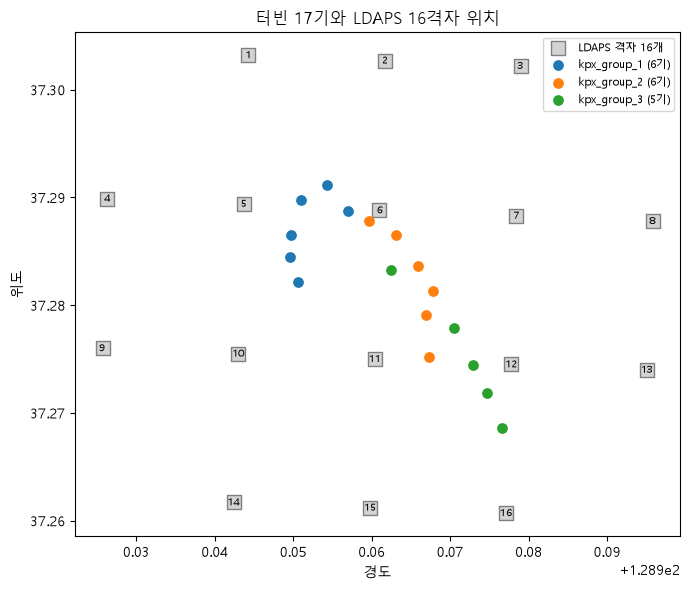

In [104]:
# 매핑이 제대로 됐는지 눈으로 확인 (좌표 파싱을 틀리면 여기서 터빈이 격자 밖으로 튀어나감)
fig, ax = plt.subplots(figsize=(7, 6))  # 그래프 한 칸
ax.scatter(grid_coords["longitude"], grid_coords["latitude"], marker="s", s=90, c="lightgray", edgecolors="gray", label="LDAPS 격자 16개")
for gid, row in grid_coords.iterrows():  # 격자마다 번호 적기
    ax.annotate(str(gid), (row["longitude"], row["latitude"]), fontsize=7, ha="center", va="center")
colors = {"kpx_group_1": "tab:blue", "kpx_group_2": "tab:orange", "kpx_group_3": "tab:green"}  # 그룹별 색
for grp, part in tmeta.groupby("group"):  # 그룹마다 터빈 위치 찍기
    ax.scatter(part["lon"], part["lat"], s=45, c=colors[grp], label=f"{grp} ({len(part)}기)")
ax.set_xlabel("경도")  # x축 이름
ax.set_ylabel("위도")  # y축 이름
ax.set_title("터빈 17기와 LDAPS 16격자 위치")  # 제목
ax.legend(fontsize=8)  # 범례
plt.tight_layout()  # 여백 정리
plt.show()  # 출력

In [105]:
# 4단계: 가중치를 실제 예보값에 적용
# 격자별로 이미 계산해둔 파생변수(공기밀도 등)를 여기서 공간 가중평균함 (비선형 계산을 먼저 한 이유가 이것)
IDW_FEATURES = [
    "u10", "v10", "ws10", "air_density", "wind_power_density",  # 바람·밀도·에너지
    "t2m", "dpt2m", "rh2m", "q2m", "t_dew_diff",  # 기온·습도
    "sp", "prmsl", "blh", "surface_h", "blws",  # 기압·경계층·고도
    "u50_range", "v50_range", "ws10_spatial_range",  # 변동성
    "lcc", "mcc", "hcc", "vlcdc",  # 운량
    "ncpcp", "ls_prate", "nd_sw", "nd_lw",  # 강수·복사
]

times = np.sort(ldaps["forecast_kst_dtm"].unique())  # 예보 대상 시각 (26,304개)
idw_values = {}  # 피처별 (시각 × 그룹) 결과를 담을 사전
for feat in IDW_FEATURES:  # 피처마다
    mat = ldaps.pivot(index="forecast_kst_dtm", columns="grid_id", values=feat).reindex(columns=grid_coords.index)  # 시각 × 격자
    idw_values[feat] = mat.to_numpy() @ G.T  # (시각×16) @ (16×3) = 시각 × 그룹. 한 번의 행렬곱으로 끝남

group_frames = []  # 그룹별 조각
for j, grp in enumerate(GROUPS):  # 그룹마다
    part = pd.DataFrame({feat: idw_values[feat][:, j] for feat in IDW_FEATURES})  # 이 그룹 몫만 꺼내기
    part.insert(0, "group", grp)  # 그룹 이름
    part.insert(0, "forecast_kst_dtm", times)  # 예보 대상 시각
    group_frames.append(part)

ldaps_group_idw = pd.concat(group_frames, ignore_index=True)  # 세로로 합치기

# 풍향은 가중평균한 U·V에서 다시 복원 (각도를 직접 가중평균하면 안 됨)
ldaps_group_idw["ws10_vector"] = np.sqrt(ldaps_group_idw["u10"] ** 2 + ldaps_group_idw["v10"] ** 2)  # 벡터 평균 풍속
ldaps_group_idw["wd10"] = (np.degrees(np.arctan2(-ldaps_group_idw["u10"], -ldaps_group_idw["v10"])) + 360) % 360  # 풍향
ldaps_group_idw["wd10_sin"] = np.sin(np.deg2rad(ldaps_group_idw["wd10"]))  # 순환값 처리
ldaps_group_idw["wd10_cos"] = np.cos(np.deg2rad(ldaps_group_idw["wd10"]))  # 순환값 처리
ldaps_group_idw["ws10_2"] = ldaps_group_idw["ws10"] ** 2  # 풍속 제곱
ldaps_group_idw["ws10_3"] = ldaps_group_idw["ws10"] ** 3  # 풍속 세제곱 (풍력에너지가 세제곱에 비례)

print(f"그룹별 공간가중 LDAPS 피처: {len(ldaps_group_idw):,}행 × {ldaps_group_idw.shape[1]}열 (26,304 시각 × 3 그룹)")
print("\n그룹별 평균 풍속 - 세 그룹 값이 서로 달라야 공간 매핑이 의미가 있음")
print(ldaps_group_idw.groupby("group")[["ws10", "ws10_vector", "air_density", "surface_h"]].mean().round(4))

그룹별 공간가중 LDAPS 피처: 78,912행 × 34열 (26,304 시각 × 3 그룹)

그룹별 평균 풍속 - 세 그룹 값이 서로 달라야 공간 매핑이 의미가 있음
               ws10  ws10_vector  air_density  surface_h
group                                                   
kpx_group_1  4.9039       4.8869       1.1154   993.4741
kpx_group_2  5.0767       5.0605       1.1156   988.4212
kpx_group_3  5.1344       5.1172       1.1176   968.2889


### 10-2. 비교용: 16격자 단순 통계 버전도 같이 만들기

10-1이 정말 나은지는 검증 성능으로 확인해야 함. 그래서 지금까지 쓰던 **16격자 단순 통계** 버전도 나란히 만들어 저장한다.
평균만 넣지 않고 표준편차·최소·최대·분위수까지 넣어서, 06 문서 2.12에서 말한 "평균 풍속 8m/s 하나로는
전 격자 8m/s인 경우와 절반 4m/s·절반 12m/s인 경우를 구분할 수 없다"는 문제를 조금이라도 줄인다.

In [106]:
STAT_FEATURES = ["ws10", "u10", "v10", "air_density", "wind_power_density", "t2m", "q2m", "sp", "blh", "rh2m", "lcc", "ncpcp"]  # 통계를 낼 피처

ldaps["ws10_2"] = ldaps["ws10"] ** 2  # 격자별 풍속 제곱 (평균 내기 전에 먼저 제곱해야 함)
ldaps["ws10_3"] = ldaps["ws10"] ** 3  # 격자별 풍속 세제곱
ldaps["rho_ws3"] = ldaps["air_density"] * ldaps["ws10"] ** 3  # 격자별 밀도×풍속³

gt = ldaps.groupby("forecast_kst_dtm")  # 시각별 묶음 (한 묶음에 격자 16개)
stats = {
    "mean": gt[STAT_FEATURES].mean(),  # 격자 평균
    "std": gt[STAT_FEATURES].std(),  # 격자 간 표준편차 (공간 변동성)
    "min": gt[STAT_FEATURES].min(),  # 최솟값
    "max": gt[STAT_FEATURES].max(),  # 최댓값
}
ldaps_grid_stats = pd.concat(stats, axis=1)  # 통계별로 옆으로 붙이기
ldaps_grid_stats.columns = [f"ldaps_{col}_{stat}" for stat, col in ldaps_grid_stats.columns]  # ldaps_ws10_mean 형태로 이름 정리

q_stats = gt["ws10"].quantile([0.25, 0.5, 0.75]).unstack()  # 풍속 분위수
q_stats.columns = ["ldaps_ws10_q25", "ldaps_ws10_median", "ldaps_ws10_q75"]  # 이름 정리
ldaps_grid_stats = ldaps_grid_stats.join(q_stats)  # 분위수 붙이기

# 세제곱 계열은 '격자별로 먼저 계산 -> 평균' 순서를 지킨 값 (평균 풍속을 세제곱한 값과 다르다)
ldaps_grid_stats["ldaps_mean_ws2"] = gt["ws10_2"].mean()  # 평균(풍속²)
ldaps_grid_stats["ldaps_mean_ws3"] = gt["ws10_3"].mean()  # 평균(풍속³)
ldaps_grid_stats["ldaps_mean_rho_ws3"] = gt["rho_ws3"].mean()  # 평균(밀도×풍속³)
ldaps_grid_stats["ldaps_ws10_range"] = ldaps_grid_stats["ldaps_ws10_max"] - ldaps_grid_stats["ldaps_ws10_min"]  # 격자 간 풍속 폭

# 풍향은 격자 U·V 평균에서 복원
ldaps_grid_stats["ldaps_wd10"] = (np.degrees(np.arctan2(-ldaps_grid_stats["ldaps_u10_mean"], -ldaps_grid_stats["ldaps_v10_mean"])) + 360) % 360
ldaps_grid_stats = ldaps_grid_stats.reset_index()  # 시각을 컬럼으로

# 평균 풍속을 세제곱한 값 vs 세제곱의 평균 — 정말 다른지 확인 (06 문서 2.12의 요지)
cube_of_mean = ldaps_grid_stats["ldaps_ws10_mean"] ** 3  # (평균 풍속)³
mean_of_cube = ldaps_grid_stats["ldaps_mean_ws3"]  # 평균(풍속³)
print(f"16격자 단순 통계 버전: {ldaps_grid_stats.shape[0]:,}행 × {ldaps_grid_stats.shape[1]}열")
print(f"\n(평균 풍속)³ 평균 = {cube_of_mean.mean():.1f}")
print(f"평균(풍속³)   평균 = {mean_of_cube.mean():.1f}")
print(f"-> 평균을 먼저 내면 발전 가능 에너지를 {(1 - cube_of_mean.mean() / mean_of_cube.mean()) * 100:.1f}% 과소평가함. 순서가 중요하다는 증거")

16격자 단순 통계 버전: 26,304행 × 57열

(평균 풍속)³ 평균 = 216.0
평균(풍속³)   평균 = 227.2
-> 평균을 먼저 내면 발전 가능 에너지를 4.9% 과소평가함. 순서가 중요하다는 증거


### 10-3. 시간 정보와 예보 시간 변화량
발전량은 월별 패턴이 반복되니까 계절 정보가 필요하고, 램프(급격한 증감) 구간을 잡으려면 변화량도 필요함.

주의: 시(hour)와 연중일(day of year)은 순환값이라 그냥 숫자로 넣으면 23시와 0시가 멀리 떨어진 값이 됨. sin·cos으로 넣는다.

In [107]:
feat = ldaps_group_idw.copy()  # 공간가중 피처에 시간 정보를 붙여나갈 표
feat = feat.sort_values(["group", "forecast_kst_dtm"], ignore_index=True)  # 그룹별 시간순 (변화량 계산 전에 필수)

# 예보 시간 메타를 다시 붙인다 (2절에서 만든 값. 격자마다 같으니 시각 단위로 하나만 꺼내옴)
time_meta = ldaps.groupby("forecast_kst_dtm")[["lead_hour", "target_hour", "forecast_issue_date"]].first().reset_index()
feat = feat.merge(time_meta, on="forecast_kst_dtm", how="left")  # 선행시간·대상시각·발행일 붙이기

# --- 시간 정보 ---
dt = feat["forecast_kst_dtm"]  # 예보 대상 시각
feat["hour_sin"] = np.sin(2 * np.pi * dt.dt.hour / 24)  # 하루 주기를 원으로 (23시와 0시가 붙어있게)
feat["hour_cos"] = np.cos(2 * np.pi * dt.dt.hour / 24)  # 위와 같은 이유
feat["doy_sin"] = np.sin(2 * np.pi * dt.dt.dayofyear / 365.25)  # 1년 주기를 원으로 (12월 31일과 1월 1일이 붙어있게)
feat["doy_cos"] = np.cos(2 * np.pi * dt.dt.dayofyear / 365.25)  # 위와 같은 이유
feat["month"] = dt.dt.month  # 월
feat["season"] = (dt.dt.month % 12 // 3).map({0: "winter", 1: "spring", 2: "summer", 3: "autumn"})  # 계절 (12,1,2=겨울)

# --- 예보 시간 변화량 (그룹별로 따로 계산해야 함. 안 그러면 그룹 경계에서 엉뚱한 차이가 생긴다) ---
by_group = feat.groupby("group", observed=True)  # 그룹별 묶음
feat["ws_diff_1h"] = by_group["ws10"].diff(1)  # 1시간 풍속 변화량
feat["ws_diff_3h"] = by_group["ws10"].diff(3)  # 3시간 풍속 변화량
feat["u_diff_1h"] = by_group["u10"].diff(1)  # U 성분 변화량
feat["v_diff_1h"] = by_group["v10"].diff(1)  # V 성분 변화량
feat["ws_next3h_max"] = by_group["ws10"].transform(lambda s: s.shift(-1).rolling(3, min_periods=1).max())  # 다음 3시간 최대 풍속
feat["ws_next3h_min"] = by_group["ws10"].transform(lambda s: s.shift(-1).rolling(3, min_periods=1).min())  # 다음 3시간 최소 풍속
feat["ws_ramp_rate"] = feat["ws_diff_1h"].abs()  # 풍속 램프율 (변화 속도)
feat["wd_rotation"] = ((by_group["wd10"].diff(1) + 180) % 360 - 180).abs()  # 풍향 회전속도 (-180~180으로 감아서 절댓값)

# 주의: 01:00 자료의 '1시간 전'은 전날 발행분의 마지막 시각임. 대상 시각은 연속이지만 발행분은 다르다
# 필요하면 lead_hour == 12(하루 첫 대상 시각)인 행의 변화량을 따로 취급할 수 있게 lead_hour를 남겨둠
print(f"시간 파생 추가 후: {len(feat):,}행 × {feat.shape[1]}열")
print("\n계절별 평균 풍속 (겨울에 높고 늦여름에 낮은 패턴이 나와야 01 노트북 결과와 맞다)")
print(feat.groupby(["season", "group"], observed=True)["ws10"].mean().unstack().round(3))

시간 파생 추가 후: 78,912행 × 51열

계절별 평균 풍속 (겨울에 높고 늦여름에 낮은 패턴이 나와야 01 노트북 결과와 맞다)
group   kpx_group_1  kpx_group_2  kpx_group_3
season                                       
autumn        4.407        4.490        4.501
spring        5.142        5.297        5.345
summer        4.402        4.473        4.461
winter        5.673        6.058        6.244


In [108]:
# LDAPS 예보 대상 시각(forecast_kst_dtm)과 SCADA 시간 칸(hour_end)을 맞춰 붙인다
# 둘 다 '1시간 집계 종료 시각' 기준이라 이름만 다르고 같은 의미
train_merged = feat.merge(
    scada_group_hourly.rename(columns={"hour_end": "forecast_kst_dtm"}),  # SCADA 쪽 시간 컬럼 이름을 맞춰줌
    on=["forecast_kst_dtm", "group"], how="left",  # 예보 시각 전체를 기준으로 왼쪽 결합 (SCADA가 없는 구간은 NaN)
)

# 16격자 단순 통계 버전도 같은 표에 붙여둔다 (컬럼 이름이 ldaps_ 로 시작해서 구분됨)
train_merged = train_merged.merge(ldaps_grid_stats, on="forecast_kst_dtm", how="left")

print(f"최종 결합표: {len(train_merged):,}행 × {train_merged.shape[1]}열")
print(f"기간: {train_merged['forecast_kst_dtm'].min()} ~ {train_merged['forecast_kst_dtm'].max()}")
print("\n그룹별 SCADA 결합 상황 (그룹3은 2023년부터라 결측이 많은 게 정상)")
print(train_merged.groupby("group", observed=True).agg(
    행수=("forecast_kst_dtm", "size"),
    SCADA있음=("scada_power_kwh", "count"),
    SCADA결측=("scada_power_kwh", lambda s: int(s.isna().sum())),
))

최종 결합표: 78,912행 × 120열
기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00

그룹별 SCADA 결합 상황 (그룹3은 2023년부터라 결측이 많은 게 정상)
                행수  SCADA있음  SCADA결측
group                               
kpx_group_1  26304    26179      125
kpx_group_2  26304    26243       61
kpx_group_3  26304    16343     9961


> **주의: SCADA 컬럼(`scada_*`)은 최종 모델 입력이 아니다**
>
> 평가 기간에는 LDAPS와 GFS만 제공되고 SCADA는 없음. `scada_ws_scalar` 같은 걸 학습표에 그냥 넣으면
> 학습 성능은 아주 좋아지지만 테스트에서는 그 값을 만들 수가 없다.
>
> 그래서 이 표의 SCADA 컬럼은 다음 용도로만 쓴다
> - LDAPS 10m 풍속 -> 현장 허브 높이 풍속 **보정 모델의 정답값**
> - 파워커브 추정, 이상 상태 분석
>
> 그리고 그 보정 모델을 주 모델 입력으로 쓸 때는 학습 구간에 **Out-of-Fold 예측값**을 만들어야 함.
> 전체 기간으로 학습한 보정 모델로 같은 기간을 다시 예측하면 간접 누수가 생긴다.

### 10-5. 전처리 검증

시간 정합성 확인

`train_labels.csv`는 이 노트북의 전처리 대상이 아니라서 가공하지 않고, **검증용 참조로만** 한 번 읽는다.
(최종 학습 정답은 항상 공식 라벨을 쓰는 게 맞지만, 그건 다음 모델링 노트북에서 할 일)

확인할 것

- `ceil` 기준으로 만든 시간 칸이 공식 라벨과 정말 맞는지 (±1시간 밀리면 성능 상한이 크게 낮아짐)
- 그룹3의 2022년이 0으로 채워지지 않고 비어 있는지
- 공기밀도가 현실 범위인지

In [109]:
labels_ref = pd.read_csv(TRAIN_DIR / "train_labels.csv", encoding="utf-8-sig")  # 검증용 참조 (가공하지 않음)
labels_ref["kst_dtm"] = pd.to_datetime(labels_ref["kst_dtm"])  # 시각 변환
labels_long = labels_ref.melt(id_vars="kst_dtm", value_vars=GROUPS, var_name="group", value_name="label_kwh")  # 세로 형태로

align_rows = []  # 시각 정합 검사 결과
for shift in [-1, 0, 1]:  # 우리 시간 칸을 -1/0/+1시간 밀어보며 비교
    moved = scada_group_hourly[["hour_end", "group", "scada_power_kwh"]].copy()  # 집계 결과 사본
    moved["kst_dtm"] = moved["hour_end"] + pd.Timedelta(hours=shift)  # 시각을 밀기
    cmp = moved.merge(labels_long, on=["kst_dtm", "group"], how="inner").dropna(subset=["scada_power_kwh", "label_kwh"])
    for grp, part in cmp.groupby("group", observed=True):  # 그룹별로
        align_rows.append({
            "그룹": grp,
            "시각 이동": f"{shift:+d}시간",
            "비교 행수": len(part),
            "MAE(kWh)": round((part["scada_power_kwh"] - part["label_kwh"]).abs().mean(), 1),
            "상관계수": round(part["scada_power_kwh"].corr(part["label_kwh"]), 4),
            "SCADA÷라벨 중앙값": round((part["scada_power_kwh"] / part["label_kwh"].replace(0, np.nan)).median(), 4),
        })

align_report = pd.DataFrame(align_rows).sort_values(["그룹", "시각 이동"])  # 정합 검사 표
print("시각 정합 검사: '+0시간'의 MAE가 가장 작아야 우리 ceil 규칙이 맞다는 뜻")
print("(이동이 0이 아닐 때 더 좋게 나오면 시간 칸이 밀린 것이므로 2절부터 다시 봐야 함)")
align_report

시각 정합 검사: '+0시간'의 MAE가 가장 작아야 우리 ceil 규칙이 맞다는 뜻
(이동이 0이 아닐 때 더 좋게 나오면 시간 칸이 밀린 것이므로 2절부터 다시 봐야 함)


,그룹,시각 이동,비교 행수,MAE(kWh),상관계수,SCADA÷라벨 중앙값
3,kpx_group_1,+0시간,26075,130.9,0.9998,1.0148
6,kpx_group_1,+1시간,26074,1202.1,0.9598,1.0055
0,kpx_group_1,-1시간,26075,1273.1,0.9549,1.0082
4,kpx_group_2,+0시간,26140,124.7,0.9998,1.0110
7,kpx_group_2,+1시간,26139,1185.3,0.9646,1.0039
1,kpx_group_2,-1시간,26140,1266.7,0.9597,1.0047
5,kpx_group_3,+0시간,16343,282.3,0.9967,0.9963
8,kpx_group_3,+1시간,16342,1020.5,0.9559,0.9860
2,kpx_group_3,-1시간,16342,1332.5,0.9261,0.9666


In [110]:
# 나머지 검증 항목들을 한 번에 확인
final_checks = []  # 결과를 담을 리스트


def add_final(item, result, detail):
    # 최종 검증 결과를 표로 모으는 함수 (재사용)
    final_checks.append({"검사항목": item, "통과": "O" if result else "X", "내용": detail})


best = align_report.loc[align_report.groupby("그룹")["MAE(kWh)"].idxmin()]  # 그룹별로 MAE가 가장 작은 이동량
add_final("시각 정합(+0시간이 최적)", (best["시각 이동"] == "+0시간").all(), f"그룹별 최적 이동 = {best['시각 이동'].tolist()}")

g3_2022 = train_merged[(train_merged["group"] == "kpx_group_3") & (train_merged["forecast_kst_dtm"].dt.year == 2022)]
add_final("그룹3 2022년이 비어 있음", g3_2022["scada_power_kwh"].isna().all(), f"2022년 {len(g3_2022)}행 전부 NaN (0으로 채우지 않았음)")

rho_ok = train_merged["air_density"].between(0.9, 1.4).all()  # 공기밀도 현실 범위
add_final("공기밀도 0.9~1.4 kg/m³", rho_ok, f"{train_merged['air_density'].min():.4f} ~ {train_merged['air_density'].max():.4f}")

rows_ok = len(train_merged) == 26304 * 3  # 시각 26,304 × 그룹 3
add_final("행 수 = 시각×그룹", rows_ok, f"{len(train_merged):,}행 (기대 {26304 * 3:,})")

dup_ok = not train_merged.duplicated(["forecast_kst_dtm", "group"]).any()  # 결합 중 행이 불어나지 않았는지
add_final("(시각, 그룹) 중복 없음", dup_ok, "결합 과정에서 행이 불어나지 않음")

ws_diff_group = train_merged.groupby("group", observed=True)["ws10"].mean()  # 그룹별 평균 풍속
add_final("그룹별 LDAPS 풍속이 서로 다름", ws_diff_group.nunique() == 3, f"{ws_diff_group.round(4).to_dict()}")

cap_ok = (train_merged["capacity_factor"].dropna() <= 1.05).all()  # 설비이용률이 100%를 크게 넘지 않는지
add_final("설비이용률 <= 105%", cap_ok, f"최대 {train_merged['capacity_factor'].max():.3f}")

final_report = pd.DataFrame(final_checks)  # 최종 검증 표
print("최종 검증")
final_report

최종 검증


,검사항목,통과,내용
0,시각 정합(+0시간이 최적),O,"그룹별 최적 이동 = ['+0시간', '+0시간', '+0시간']"
1,그룹3 2022년이 비어 있음,O,2022년 8759행 전부 NaN (0으로 채우지 않았음)
2,공기밀도 0.9~1.4 kg/m³,O,1.0232 ~ 1.2543
3,행 수 = 시각×그룹,O,"78,912행 (기대 78,912)"
4,"(시각, 그룹) 중복 없음",O,결합 과정에서 행이 불어나지 않음
5,그룹별 LDAPS 풍속이 서로 다름,O,"{'kpx_group_1': 4.9039, 'kpx_group_2': 5.0767,..."
6,설비이용률 <= 105%,O,최대 1.004


In [111]:
# 다음(모델링) 노트북이 바로 받아쓸 수 있게 prep/ 폴더에 저장
# 10분 단위 표는 240만 행이라 그대로 CSV로 쓰면 파일이 너무 커짐 -> gzip으로 압축해서 저장
turbine_10min_cols = [
    "kst_dtm", "hour_end", "turbine", "group", "power_raw", "power_clean", "power_filled",
    "ws_raw", "ws_clean", "ws_filled", "wd_raw", "wd_clean", "u_scada", "v_scada",
    "power_qc_flag", "n_valid_in_hour", "na_run_len", "is_power_interpolated",
] + FLAG_COLS  # 원본·정제·플래그를 모두 남겨서 나중에 되돌려 볼 수 있게

outputs = {
    "scada_turbine_10min.csv.gz": scada[turbine_10min_cols],  # 터빈 단위 10분 정제값 + QC 플래그
    "scada_turbine_hourly.csv": agg_turbine,  # 터빈 단위 시간별 집계
    "scada_group_hourly.csv": scada_group_hourly,  # 그룹 단위 시간별 발전량·풍속·풍향 + coverage
    "ldaps_group_idw.csv": ldaps_group_idw,  # 그룹별 공간가중(IDW) LDAPS 피처
    "ldaps_grid_stats.csv": ldaps_grid_stats,  # 16격자 단순 통계 버전 (비교용)
    "train_merged.csv": train_merged,  # 최종 결합표
}

# float_format을 안 주면 소수점이 17자리까지 찍혀서 파일이 두 배 넘게 커진다. 유효숫자 6자리면 기상값·발전량 모두 충분
for fname, df in outputs.items():  # 파일마다
    path = PREP_DIR / fname  # 저장 경로
    df.to_csv(path, index=False, encoding="utf-8-sig", float_format="%.6g")  # 확장자가 .gz면 pandas가 알아서 압축함
    print(f"{fname}: {len(df):,}행 × {df.shape[1]}열, {path.stat().st_size / 1e6:.1f} MB")

# 품질 리포트도 하나로 묶어서 저장 (전처리 근거를 남겨두는 용도)
qc_report = pd.concat([
    contract_report.assign(구분="1-2 데이터 계약 검사"),
    ldaps_qc_report.rename(columns={"검사": "검사항목", "결과": "내용"}).assign(구분="4-1 LDAPS 품질검사", 대상="ldaps"),
    final_report.assign(구분="10-5 최종 검증", 대상="전체"),
], ignore_index=True)[["구분", "대상", "검사항목", "통과", "내용"]]  # 세 표의 컬럼 순서를 하나로 맞추기
qc_report.to_csv(PREP_DIR / "qc_report.csv", index=False, encoding="utf-8-sig")  # 저장
print(f"qc_report.csv: {len(qc_report)}행")
print(f"\nprep/ 폴더 총 용량: {sum(f.stat().st_size for f in PREP_DIR.glob('*')) / 1e6:.0f} MB")
print("(git에 올릴 생각이면 prep/ 는 .gitignore에 넣는 걸 권함. 코드만 있으면 언제든 다시 만들 수 있는 파일들이라)")

# 저장한 파일을 다시 읽어서 다음 노트북이 바로 쓸 수 있는 상태인지 확인
reloaded = pd.read_csv(PREP_DIR / "train_merged.csv", encoding="utf-8-sig", parse_dates=["forecast_kst_dtm"])
print(f"\n다시 읽은 train_merged: {len(reloaded):,}행 × {reloaded.shape[1]}열")
print(f"기간: {reloaded['forecast_kst_dtm'].min()} ~ {reloaded['forecast_kst_dtm'].max()}")
print(f"결측률이 50%를 넘는 컬럼: {[c for c in reloaded.columns if reloaded[c].isna().mean() > 0.5]}")

scada_turbine_10min.csv.gz: 2,420,148행 × 27열, 63.4 MB
scada_turbine_hourly.csv: 403,368행 × 19열, 56.3 MB
scada_group_hourly.csv: 78,912행 × 15열, 8.9 MB
ldaps_group_idw.csv: 78,912행 × 34열, 21.5 MB
ldaps_grid_stats.csv: 26,304행 × 57열, 12.0 MB
train_merged.csv: 78,912행 × 120열, 72.5 MB
qc_report.csv: 26행

prep/ 폴더 총 용량: 235 MB
(git에 올릴 생각이면 prep/ 는 .gitignore에 넣는 걸 권함. 코드만 있으면 언제든 다시 만들 수 있는 파일들이라)

다시 읽은 train_merged: 78,912행 × 120열
기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
결측률이 50%를 넘는 컬럼: []


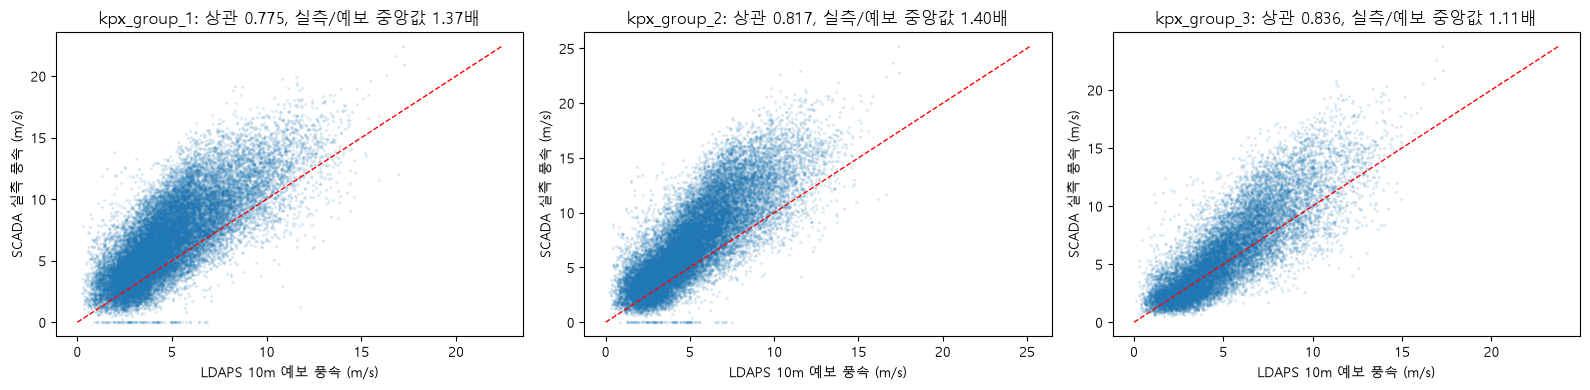

In [112]:
# 마지막으로 눈으로 확인: LDAPS 예보 풍속과 SCADA 실측 풍속이 얼마나 닮았나
# '10m 예보풍속 -> 허브 높이(117m) 현장풍속 보정'이 다음 과제라는 걸 여기서 확인할 수 있다
fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 그룹 3개
for ax, grp in zip(axes, GROUPS):  # 그룹마다
    part = train_merged[train_merged["group"] == grp].dropna(subset=["scada_ws_scalar", "ws10"])  # 둘 다 있는 시각만
    ax.scatter(part["ws10"], part["scada_ws_scalar"], s=2, alpha=0.1)  # 예보 vs 실측 산점도
    lim = [0, max(part["ws10"].max(), part["scada_ws_scalar"].max())]  # 축 범위
    ax.plot(lim, lim, "r--", linewidth=1)  # 기울기 1인 참조선 (여기 붇어있으면 보정이 필요 없다는 뜻)
    corr = part["ws10"].corr(part["scada_ws_scalar"])  # 상관계수
    ratio = (part["scada_ws_scalar"] / part["ws10"].replace(0, np.nan)).median()  # 실측÷예보 중앙값
    ax.set_title(f"{grp}: 상관 {corr:.3f}, 실측/예보 중앙값 {ratio:.2f}배")  # 제목
    ax.set_xlabel("LDAPS 10m 예보 풍속 (m/s)")  # x축
    ax.set_ylabel("SCADA 실측 풍속 (m/s)")  # y축
plt.tight_layout()  # 여백 정리
plt.show()  # 출력

## 11. 정리

**확정**

- 시간 규칙: SCADA 10분값은 `ceil("1h")`로 묶고 **합계**(÷6 아님)를 쓴다. 10-5절 정합 검사에서 `+0시간`이 최적으로 나오는 것을 확인
- 단위: LDAPS 기온 **K**, 비습 **kg/kg**, 기압 **Pa**. 04 문서의 공기밀도 식을 그대로 적용 가능
- LDAPS 구조: 매 시각 16격자, 중복 없음, 사용 가능 시각은 13시, 선행시간 12~35시간
- SCADA 10분 시간축은 VESTAS·UNISON 둘 다 누락 없음

**개선**

1. `sum(axis=1)`에 `min_count` 추가 -> 9절. 결측이 발전량 0으로 바뀌는 사고를 막았음
2. 16격자 단순 평균을 그룹별 거리 가중으로 변경 -> 10-1절. 단순평균 버전도 같이 저장해서 나중에 비교
3. 풍향 각도 평균 대신 U·V 집계 후 방향 복원 -> 8-2·9절
4. SCADA를 최종 모델 입력에서 빼고 LDAPS 보정용으로 재정의 -> 10-4절 주의 문구
5. `power/ws³` 효율은 참고용으로만. 파워커브 잔차 기반 효율은 모델링 노트북에서 -> 8-3절

**모델링에서 A/B로 비교할 것**

- `ldaps_group_idw` (공간가중) vs `ldaps_grid_stats` (16격자 단순통계) — 어느 쪽이 검증 성능이 좋은지 비교
- `scada_power_kwh` (6/6 엄격) vs `scada_power_kwh_relaxed` (5/6 허용) — 보정 모델 학습 정답으로 어느 쪽이 나은지 비교
- `coverage_ratio`가 낮은 시간을 학습에서 뺄지 말지
- 목표값을 발전량 그대로 쓸지 `capacity_factor`(설비용량 정규화)로 쓸지

**아직 남은 일**

- 10m 예보풍속 -> 허브 높이(117m) 현장풍속 보정
- 그룹별 정상 파워커브 추정 후 `power_residual = 실제 - 기대`로 후류 효과 판단
- GFS 데이터는 이번 범위에서 제외했음. 80m·100m 바람이 허브 높이에 더 가까우니 나중에 추가해볼 만함
- 검증은 상관계수가 아니라 대회 지표인 **1-NMAE**와 **FICR**로. 최종 예측은 `clip(0, 그룹 설비용량)` 필수
